In [1]:
import os
import re
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from matplotlib.font_manager import FontProperties
import pandas as pd
import datetime
import copy
# import scipy.stats as st
# from scipy.stats import linregress
# import seaborn as sns
import colorcet as cc
# from sklearn.neighbors import KernelDensity
# from scipy.ndimage import label, binary_dilation, generate_binary_structure, filters, iterate_structure
import warnings

In [2]:
def list_dirs(in_dir):
    """
    List sub-directories.
    """
    dirs = []
    for it in os.scandir(in_dir):
        if it.is_dir():
            dirs.append(it.path)
    return dirs

def find_lasso_files(start_dates, root_datadir, in_basename, domain):
    files = []
    # Loop over dates
    for ii in range(0, len(start_dates)):
        # Get sub-directories (cases)
        idate = start_dates[ii]
        case_dirs = list_dirs(f'{root_datadir}{idate}/')
        if len(case_dirs) > 0:
            # Loop over cases
            for icase in case_dirs:
                # Find config sub-directories
                # config_dirs = list_dirs(icase)
                config_dirs = [f'{icase}/base/']
                if len(config_dirs) > 0:
                    # Loop over configs
                    for iconfig in config_dirs:
                        # Find track stats file
                        fname = sorted(glob.glob(f'{iconfig}{domain}/stats/{in_basename}*nc'))
                        if len(fname) > 0:
                            # Replace all occurrences of double slashes with a single slash
                            _fname = re.sub(r'/+', '/', fname[0])
                            files.append(_fname)
    return files

In [3]:
# LASSO case dates
start_dates = [
    "20181129", 
    "20181204",
    "20181205", 
    # "20181219", 
    "20190122", 
    "20190123",
    "20190125",
    "20190129",
    "20190208",
]

# LASSO tracking directory
rootdir_les = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/'
rootdir_meso = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/'
in_basename = 'trackstats_20'
in_basename_w = 'stats_3d_w_'
in_basename_wmask = 'stats_2d_wmask_'
in_basename_env = 'stats_1d_env_2location_'

# figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/envs_cases/'
figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI_2.5km+2h/'

# Domain 4 boundaries
# lon_range = [-65.4, -63.1]
# lat_range = [-33.3, -30.8]
# lon_range = [-65., -63.1]
lon_range = [-65., -63.3]
lat_range = [-33., -30.8]
lifetime_range = [15, 1000]

# Environment location (0: fixed site, 1: CI location)
env_loc = 1
# Time for representative environment
time_env = -3

# Find LASSO files
files_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename, 'd2')
files_d3 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd3')
files_d4 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd4')
# wfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_w, 'd2')
# wfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd3')
# wfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd4')
wmaskfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_wmask, 'd2')
wmaskfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_wmask, 'd3')
wmaskfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_wmask, 'd4')
efiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_env, 'd2')
efiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_env, 'd3')
efiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_env, 'd4')

print(f'Number of stats files (D2): {len(files_d2)}')
# print(f'Number of W files (D2): {len(wfiles_d2)}')
print(f'Number of Wmask files (D2): {len(wmaskfiles_d2)}')
print(f'Number of ENV files (D2): {len(efiles_d2)}')

print(f'Number of stats files (D3): {len(files_d3)}')
# print(f'Number of W files (D3): {len(wfiles_d3)}')
print(f'Number of Wmask files (D3): {len(wmaskfiles_d3)}')
print(f'Number of ENV files (D3): {len(efiles_d3)}')

print(f'Number of stats files (D4): {len(files_d4)}')
# print(f'Number of W files (D4): {len(wfiles_d4)}')
print(f'Number of Wmask files (D4): {len(wmaskfiles_d4)}')
print(f'Number of ENV files (D4): {len(efiles_d4)}')

# files_d2, files_d3, files_d4, efiles_d2, efiles_d3, efiles_d4

Number of stats files (D2): 17
Number of Wmask files (D2): 17
Number of ENV files (D2): 17
Number of stats files (D3): 17
Number of Wmask files (D3): 17
Number of ENV files (D3): 17
Number of stats files (D4): 17
Number of Wmask files (D4): 17
Number of ENV files (D4): 17


In [4]:
_file_part = files_d2[0].strip(os.sep).split(os.sep)
print(_file_part)
print(f"Forcing: {_file_part[-5]}")

['gpfs', 'wolf2', 'arm', 'atm131', 'proj-shared', 'zfeng', 'cacti', 'meso', '20181129', 'gefs03', 'base', 'd2', 'stats', 'trackstats_20181129.1200_20181130.0000.nc']
Forcing: gefs03


In [5]:
_file_part = files_d3[10].strip(os.sep).split(os.sep)
print(_file_part)
print(f"Forcing: {_file_part[-5]}")

['gpfs', 'wolf2', 'arm', 'atm131', 'proj-shared', 'zfeng', 'cacti', 'les', '20190123', 'gefs18', 'base', 'd3', 'stats', 'trackstats_20190123.1200_20190124.0000.nc']
Forcing: gefs18


In [6]:
_file_part = files_d4[5].strip(os.sep).split(os.sep)
print(_file_part)
print(f"Forcing: {_file_part[-5]}")

['gpfs', 'wolf2', 'arm', 'atm131', 'proj-shared', 'zfeng', 'cacti', 'les', '20181204', 'gefs18', 'base', 'd4', 'stats', 'trackstats_20181204.1200_20181205.0000.nc']
Forcing: gefs18


## Limit time window for analysis in each case
### The window is determined manually by examining cold pool animations to exclude periods when significant cold pools develop

In [7]:
# case_hours_dict_d2 = {
#     '20181129-gefs00': (12.0, 19.5),
#     '20181129-gefs03': (12.0, 20.0),
#     '20181129-gefs09': (12.0, 18.5),
#     '20181129-gefs18': (12.0, 18.5),
#     '20181204-gefs18': (12.0, 17.5),
#     '20181204-gefs19': (12.0, 19.0),
#     '20181205-gefs01': (12.0, 18.0),
#     '20181219-eda09': (12.0, 17.0),
#     '20190122-gefs01': (12.0, 21.5),
#     '20190122-gefs18': (12.0, 20.25),
#     '20190123-eda05': (12.0, 16.0),
#     '20190123-gefs18': (12.0, 17.5),
#     '20190125-eda07': (12.0, 18.5),
#     '20190125-gefs11': (12.0, 18.5),
#     '20190129-eda09': (12.0, 18.0),
#     '20190129-gefs11': (12.0, 17.5),
#     '20190208-eda03': (12.0, 19.5),
#     '20190208-eda08': (12.0, 19.75),
# }

In [8]:
# # +1 h
# case_hours_dict_d2 = {
#     '20181129-gefs00': (12.0, 20.5),
#     '20181129-gefs03': (12.0, 21.0),
#     '20181129-gefs09': (12.0, 19.5),
#     '20181129-gefs18': (12.0, 19.5),
#     '20181204-gefs18': (12.0, 18.5),
#     '20181204-gefs19': (12.0, 20.0),
#     '20181205-gefs01': (12.0, 19.0),
#     '20181219-eda09': (12.0, 18.0),
#     '20190122-gefs01': (12.0, 22.5),
#     '20190122-gefs18': (12.0, 21.25),
#     '20190123-eda05': (12.0, 17.0),
#     '20190123-gefs18': (12.0, 18.5),
#     '20190125-eda07': (12.0, 19.5),
#     '20190125-gefs11': (12.0, 19.5),
#     '20190129-eda09': (12.0, 19.0),
#     '20190129-gefs11': (12.0, 18.5),
#     '20190208-eda03': (12.0, 20.5),
#     '20190208-eda08': (12.0, 20.75),
# }

In [9]:
# +2 h
case_hours_dict_d2 = {
    '20181129-gefs00': (12.0, 21.5),
    '20181129-gefs03': (12.0, 22.0),
    '20181129-gefs09': (12.0, 20.5),
    '20181129-gefs18': (12.0, 20.5),
    '20181204-gefs18': (12.0, 19.5),
    '20181204-gefs19': (12.0, 21.0),
    '20181205-gefs01': (12.0, 20.0),
    '20181219-eda09': (12.0, 19.0),
    '20190122-gefs01': (12.0, 23.5),
    '20190122-gefs18': (12.0, 22.25),
    '20190123-eda05': (12.0, 18.0),
    '20190123-gefs18': (12.0, 19.5),
    '20190125-eda07': (12.0, 20.5),
    '20190125-gefs11': (12.0, 20.5),
    '20190129-eda09': (12.0, 20.0),
    '20190129-gefs11': (12.0, 19.5),
    '20190208-eda03': (12.0, 21.5),
    '20190208-eda08': (12.0, 21.75),
}

In [10]:
# case_hours_dict_d3 = {
#     '20181129-gefs00': (12.0, 19.5),
#     '20181129-gefs03': (12.0, 20.0),
#     '20181129-gefs09': (12.0, 19.0),
#     '20181129-gefs18': (12.0, 19.0),
#     '20181204-gefs18': (12.0, 17.5),
#     '20181204-gefs19': (12.0, 19.0),
#     '20181205-gefs01': (12.0, 18.0),
#     '20181219-eda09': (12.0, 17.0),
#     '20190122-gefs01': (12.0, 21.5),
#     '20190122-gefs18': (12.0, 20.5),
#     '20190123-eda05': (12.0, 16.0),
#     '20190123-gefs18': (12.0, 17.5),
#     '20190125-eda07': (12.0, 18.5),
#     '20190125-gefs11': (12.0, 18.5),
#     '20190129-eda09': (12.0, 18.5),
#     '20190129-gefs11': (12.0, 18.25),
#     '20190208-eda03': (12.0, 20.0),
#     '20190208-eda08': (12.0, 20.0),
# }

In [11]:
# +1 h
case_hours_dict_d3 = {
    '20181129-gefs00': (12.0, 20.5),
    '20181129-gefs03': (12.0, 21.0),
    '20181129-gefs09': (12.0, 20.0),
    '20181129-gefs18': (12.0, 20.0),
    '20181204-gefs18': (12.0, 18.5),
    '20181204-gefs19': (12.0, 20.0),
    '20181205-gefs01': (12.0, 19.0),
    '20181219-eda09': (12.0, 18.0),
    '20190122-gefs01': (12.0, 22.5),
    '20190122-gefs18': (12.0, 21.5),
    '20190123-eda05': (12.0, 17.0),
    '20190123-gefs18': (12.0, 18.5),
    '20190125-eda07': (12.0, 19.5),
    '20190125-gefs11': (12.0, 19.5),
    '20190129-eda09': (12.0, 19.5),
    '20190129-gefs11': (12.0, 19.25),
    '20190208-eda03': (12.0, 21.0),
    '20190208-eda08': (12.0, 21.0),
}

In [12]:
# Assume same cold pool development times in D4 as in D3
case_hours_dict_d4 = case_hours_dict_d3

## Read and combine data files

In [13]:
def get_casename(in_file):
    """
    Get case date, ensemble member, and config from full filename
    """
    # Example file name with file directory:
    # .../meso//20181129/gefs09/base/d2/stats/trackstats_20181129.1200_20181130.0000.nc
    # caseconfig = (in_file).split(os.path.sep)[-5]
    # ensmember = (in_file).split(os.path.sep)[-6]
    # casedate = (in_file).split(os.path.sep)[-7]
    caseconfig = (in_file).split(os.path.sep)[-4]
    ensmember = (in_file).split(os.path.sep)[-5]
    casedate = (in_file).split(os.path.sep)[-6]
    return caseconfig, ensmember, casedate

def subset_tracks(ds, time_res, lon_range, lat_range, lifetime_range, hours_range):
    # Get track min/max lat/lon
    minlon = ds['meanlon'].min(dim='times').load()
    maxlon = ds['meanlon'].max(dim='times').load()
    minlat = ds['meanlat'].min(dim='times').load()
    maxlat = ds['meanlat'].max(dim='times').load()
    # Get track lifetime in [minutes]
    lifetime = (ds['track_duration'] * time_res).load()
    # Get track start time in decimal [hours]
    start_hour = (ds['start_basetime'].dt.hour + ds['start_basetime'].dt.minute/60.).load()
    # Get track indices
    track_idx = np.where(
        (minlon >= np.min(lon_range)) & (maxlon <= np.max(lon_range)) & \
        (minlat >= np.min(lat_range)) & (maxlat <= np.max(lat_range)) & \
        (lifetime >= min(lifetime_range)) & (lifetime <= np.max(lifetime_range)) & \
        (start_hour >= np.min(hours_range)) & (start_hour <= np.max(hours_range))
    )[0]
    # Subset tracks
    dsout = ds.isel(tracks=track_idx)
    return dsout, track_idx

In [14]:
def read_subset_combine(tfiles, wmaskfiles, efiles, case_hours_dict, lon_range, lat_range, lifetime_range, time_res):
    """
    Read and subset track statistics files and combine multiple DataSets.
    
    Subsets based on:
    - Track inititial lat/lon
    - Track duration (lifetime)
    - Track initial times (different for each case)
    
    Args:
        tfiles: list
            List of track statistics files.
        wmaskfiles: list
            List of W mask statistics files.
        efiles: list
            List of environment statistics files.
        case_hours_dict: dictionary
            Case hour range dictionary.
        lon_range: list/tuple
            Longitude range to subset tracks.
        lat_range: list/tuple
            Latitude range to subset tracks.
        lifetime_range: list/tuple
            Lifetime range to subset tracks.
        time_res: float
            Time resolution of tracks [minutes].
        
    Returns:
        ds: Xarray DataSet
            Combined Xarray DataSet.
    """
    
    # Make lists for the DataSets
    dst_list = []
    dsm_list = []
    dse_list = []

    # Loop over the number of files
    # for ii in range(len(tfiles[0:2])):
    for ii in range(len(tfiles)):
        tfile = tfiles[ii]
        mfile = wmaskfiles[ii]
        efile = efiles[ii]
        caseconfig, ensmember, casedate = get_casename(tfile)
        # Make casename (date-ensmember) and look up hours
        casename = f"{casedate}-{ensmember}"
        # Get hours range for the case
        hours_range = case_hours_dict[casename]
        print(casename, hours_range)
        # print(tfile, wfile, efile)
        
        # Read tracks file
        dst = xr.open_dataset(tfile)
        # Subset tracks
        dst_s, track_idx = subset_tracks(dst, time_res, lon_range, lat_range, lifetime_range, hours_range)
        # Add a variable case (date-forcing) to the DataSet
        dst_s['case'] = casename
        # Add subsetted DataSet to the list
        dst_list.append(dst_s)
        
        # Read W mask file
        dsm = xr.open_dataset(mfile)
        # Subset W mask tracks
        dsm_s = dsm.isel(tracks=track_idx)
        dsm_list.append(dsm_s)
    
        # Read ENV file (drop 'height' dimension, i.e., profile variables)
        dse = xr.open_dataset(efile).drop_dims('height')
        # Subset ENV tracks (select CI location and representative time before CI)
        dse_s = dse.isel(tracks=track_idx).sel(location=env_loc, times=time_env)
        dse_list.append(dse_s)
    
    # Concetenante subsetted DataSets
    dst = xr.concat(dst_list, dim='tracks')
    # Renumber tracks to make it continuous
    ntracks = dst.sizes['tracks']
    dst['tracks'] = np.arange(0, ntracks)
    
    dsm = xr.concat(dsm_list, dim='tracks')
    dsm['tracks'] = np.arange(0, ntracks)

    dse = xr.concat(dse_list, dim='tracks')
    dse['tracks'] = np.arange(0, ntracks)

    # Combine 2D and 3D datasets by coordinates
    ds = xr.combine_by_coords([dst, dsm, dse], combine_attrs='drop_conflicts')
    ntimes = ds.sizes['times']
    print(f'Number of tracks: {ntracks}')

    return ds

In [15]:
time_res = 5.0  # [minute]

# Read and subset D2 data
ds_d2 = read_subset_combine(files_d2, wmaskfiles_d2, efiles_d2, case_hours_dict_d2, lon_range, lat_range, lifetime_range, time_res)
ds_d2

20181129-gefs03 (12.0, 22.0)
20181129-gefs18 (12.0, 20.5)
20181129-gefs00 (12.0, 21.5)
20181129-gefs09 (12.0, 20.5)
20181204-gefs19 (12.0, 21.0)
20181204-gefs18 (12.0, 19.5)
20181205-gefs01 (12.0, 20.0)
20190122-gefs18 (12.0, 22.25)
20190122-gefs01 (12.0, 23.5)
20190123-eda05 (12.0, 18.0)
20190123-gefs18 (12.0, 19.5)
20190125-eda07 (12.0, 20.5)
20190125-gefs11 (12.0, 20.5)
20190129-eda09 (12.0, 20.0)
20190129-gefs11 (12.0, 19.5)
20190208-eda03 (12.0, 21.5)
20190208-eda08 (12.0, 21.75)
Number of tracks: 1228


<xarray.Dataset> Size: 196MB
Dimensions:                  (tracks: 1228, times: 200, z: 40)
Coordinates:
  * tracks                   (tracks) int64 10kB 0 1 2 3 ... 1224 1225 1226 1227
  * times                    (times) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
    location                 int64 8B 1
  * z                        (z) float64 320B 250.0 500.0 ... 2e+04 2.1e+04
Data variables: (12/183)
    conv_core                (tracks) float32 5kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    conv_mask                (tracks) float32 5kB 0.0 0.0 0.0 ... 12.0 0.0 0.0
    dbz_comp                 (tracks) float32 5kB -24.3 -25.39 ... -12.72 -35.0
    echotop10                (tracks) float32 5kB nan nan nan ... nan nan
    LWP                      (tracks) float32 5kB 0.2204 0.1273 ... 0.02345
    IWP                      (tracks) float32 5kB 0.0 0.0 0.0 ... 0.0001069 0.0
    ...                       ...
    start_split_timeindex    (tracks) float64 10kB nan nan nan ... 10.0 nan nan
    start_split_cloudnumber  (tracks) float64 10kB nan nan nan ... 2.0 nan nan
    end_merge_tracknumber    (tracks) float64 10kB nan 32.0 nan ... nan nan
    end_merge_timeindex      (tracks) float64 10kB nan 10.0 nan ... 14.0 nan nan
    end_merge_cloudnumber    (tracks) float64 10kB nan 1.0 nan ... 1.0 nan nan
    case                     (tracks) <U15 74kB '20181129-gefs03' ... '201902...
Attributes: (12/14)
    title:                 Tracked cell updraft core masks & statistics
    source_trackfile:      /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/mes...
    source_W_file:         /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/mes...
    source_env_file:       /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/mes...
    time_start:            0
    time_end:              60
    ...                    ...
    cbase_depth:           0.5
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       2.5

In [16]:
ds_d2['case']

<xarray.DataArray 'case' (tracks: 1228)> Size: 74kB
array(['20181129-gefs03', '20181129-gefs03', '20181129-gefs03', ...,
       '20190208-eda08', '20190208-eda08', '20190208-eda08'], dtype='<U15')
Coordinates:
  * tracks    (tracks) int64 10kB 0 1 2 3 4 5 ... 1222 1223 1224 1225 1226 1227
    location  int64 8B 1

In [17]:
# Read and subset d3 data
ds_d3 = read_subset_combine(files_d3, wmaskfiles_d3, efiles_d3, case_hours_dict_d3, lon_range, lat_range, lifetime_range, time_res)
ds_d3

20181129-gefs03 (12.0, 21.0)
20181129-gefs18 (12.0, 20.0)
20181129-gefs00 (12.0, 20.5)
20181129-gefs09 (12.0, 20.0)
20181204-gefs19 (12.0, 20.0)
20181204-gefs18 (12.0, 18.5)
20181205-gefs01 (12.0, 19.0)
20190122-gefs18 (12.0, 21.5)
20190122-gefs01 (12.0, 22.5)
20190123-eda05 (12.0, 17.0)
20190123-gefs18 (12.0, 18.5)
20190125-eda07 (12.0, 19.5)
20190125-gefs11 (12.0, 19.5)
20190129-eda09 (12.0, 19.5)
20190129-gefs11 (12.0, 19.25)
20190208-eda03 (12.0, 21.0)
20190208-eda08 (12.0, 21.0)
Number of tracks: 1748


<xarray.Dataset> Size: 280MB
Dimensions:                  (tracks: 1748, times: 200, z: 40)
Coordinates:
  * tracks                   (tracks) int64 14kB 0 1 2 3 ... 1744 1745 1746 1747
  * times                    (times) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
    location                 int64 8B 1
  * z                        (z) float64 320B 250.0 500.0 ... 2e+04 2.1e+04
Data variables: (12/183)
    conv_core                (tracks) float32 7kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    conv_mask                (tracks) float32 7kB 0.0 0.0 0.0 ... 2.0 0.0 0.0
    dbz_comp                 (tracks) float32 7kB 18.31 6.863 ... -22.14 -35.0
    echotop10                (tracks) float32 7kB 3.75e+03 nan nan ... nan nan
    LWP                      (tracks) float32 7kB 1.1 0.6788 ... 0.04629 0.0
    IWP                      (tracks) float32 7kB 0.0 0.0 0.0 ... 0.5776 0.0 0.0
    ...                       ...
    start_split_timeindex    (tracks) float64 14kB nan nan nan ... 10.0 nan nan
    start_split_cloudnumber  (tracks) float64 14kB nan nan nan ... 4.0 nan nan
    end_merge_tracknumber    (tracks) float64 14kB 3.0 nan nan ... nan nan nan
    end_merge_timeindex      (tracks) float64 14kB 5.0 nan nan ... nan nan nan
    end_merge_cloudnumber    (tracks) float64 14kB 1.0 nan nan ... nan nan nan
    case                     (tracks) <U15 105kB '20181129-gefs03' ... '20190...
Attributes: (12/14)
    title:                 Tracked cell updraft core masks & statistics
    source_trackfile:      /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    source_W_file:         /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    source_env_file:       /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    time_start:            0
    time_end:              60
    ...                    ...
    cbase_depth:           0.5
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

In [18]:
# Read and subset d4 data
ds_d4 = read_subset_combine(files_d4, wmaskfiles_d4, efiles_d4, case_hours_dict_d4, lon_range, lat_range, lifetime_range, time_res)
ds_d4

20181129-gefs03 (12.0, 21.0)
20181129-gefs18 (12.0, 20.0)
20181129-gefs00 (12.0, 20.5)
20181129-gefs09 (12.0, 20.0)
20181204-gefs19 (12.0, 20.0)
20181204-gefs18 (12.0, 18.5)
20181205-gefs01 (12.0, 19.0)
20190122-gefs18 (12.0, 21.5)
20190122-gefs01 (12.0, 22.5)
20190123-eda05 (12.0, 17.0)
20190123-gefs18 (12.0, 18.5)
20190125-eda07 (12.0, 19.5)
20190125-gefs11 (12.0, 19.5)
20190129-eda09 (12.0, 19.5)
20190129-gefs11 (12.0, 19.25)
20190208-eda03 (12.0, 21.0)
20190208-eda08 (12.0, 21.0)
Number of tracks: 1442


<xarray.Dataset> Size: 231MB
Dimensions:                  (tracks: 1442, times: 200, z: 40)
Coordinates:
  * tracks                   (tracks) int64 12kB 0 1 2 3 ... 1438 1439 1440 1441
  * times                    (times) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
    location                 int64 8B 1
  * z                        (z) float64 320B 250.0 500.0 ... 2e+04 2.1e+04
Data variables: (12/183)
    conv_core                (tracks) float32 6kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    conv_mask                (tracks) float32 6kB 0.0 0.0 0.0 ... 0.0 12.0 0.0
    dbz_comp                 (tracks) float32 6kB 15.54 9.996 ... 26.24 -29.62
    echotop10                (tracks) float32 6kB 3.75e+03 nan ... 4e+03 nan
    LWP                      (tracks) float32 6kB 0.05833 0.1297 ... 9.539e-09
    IWP                      (tracks) float32 6kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ...                       ...
    start_split_timeindex    (tracks) float64 12kB nan nan nan ... nan nan nan
    start_split_cloudnumber  (tracks) float64 12kB nan nan nan ... nan nan nan
    end_merge_tracknumber    (tracks) float64 12kB nan 12.0 nan ... nan nan
    end_merge_timeindex      (tracks) float64 12kB nan 1.0 nan ... 3.0 nan nan
    end_merge_cloudnumber    (tracks) float64 12kB nan 3.0 nan ... 16.0 nan nan
    case                     (tracks) <U15 87kB '20181129-gefs03' ... '201902...
Attributes: (12/14)
    title:                 Tracked cell updraft core masks & statistics
    source_trackfile:      /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    source_W_file:         /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    source_env_file:       /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    time_start:            0
    time_end:              60
    ...                    ...
    cbase_depth:           0.5
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

In [19]:
# # Suppress the RuntimeWarning and FutureWarning from Xarray
# warnings.filterwarnings("ignore", category=RuntimeWarning)
# warnings.filterwarnings("ignore", category=FutureWarning)

# # Initialize an empty list to hold the datasets
# dst_list = []

# # Loop over the track stats files and add a variable 'case'
# for i, file in enumerate(files_d2):
#     ds = xr.open_dataset(file)
#     # Get parts from filename
#     _parts = file.strip(os.sep).split(os.sep)
#     _date = _parts[-6]
#     _forcing = _parts[-5]
#     _case = f"{_date}.{_forcing}"
#     # Add a variable case (date.forcing) to the DataSet
#     ds['case'] = _case
#     dst_list.append(ds)

# # Concatenante the DataSets along the 'tracks' dimension
# dst_d2 = xr.concat(dst_list, dim='tracks')
# # Renumber tracks to make it continuous
# ntracks_d2 = dst_d2.sizes['tracks']
# dst_d2['tracks'] = np.arange(0, ntracks_d2)

# # Read ENV data (LASSO D2)
# dse_d2 = xr.open_mfdataset(efiles_d2, concat_dim='tracks', combine='nested').sel(location=env_loc)
# dse_d2['tracks'] = np.arange(0, ntracks_d2)
# # dse_d2 = dse_d2.rename({'z': 'height'})

# # Combine 2D and 3D datasets by coordinates
# ds_d2 = xr.combine_by_coords([dst_d2, dse_d2], combine_attrs='drop_conflicts')
# ntimes_d2 = ds_d2.sizes['times']
# ds_d2

In [20]:
# # Suppress the RuntimeWarning and FutureWarning from Xarray
# warnings.filterwarnings("ignore", category=RuntimeWarning)
# warnings.filterwarnings("ignore", category=FutureWarning)

# # Initialize an empty list to hold the datasets
# dst_list = []

# # Loop over the track stats files and add a variable 'case'
# for i, file in enumerate(files_d3):
#     ds = xr.open_dataset(file)
#     # Get parts from filename
#     _parts = file.strip(os.sep).split(os.sep)
#     _date = _parts[-6]
#     _forcing = _parts[-5]
#     _case = f"{_date}.{_forcing}"
#     # Add a variable case (date.forcing) to the DataSet
#     ds['case'] = _case
#     dst_list.append(ds)

# # Concatenante the DataSets along the 'tracks' dimension
# dst_d3 = xr.concat(dst_list, dim='tracks')
# # Renumber tracks to make it continuous
# ntracks_d3 = dst_d3.sizes['tracks']
# dst_d3['tracks'] = np.arange(0, ntracks_d3)

# # Read ENV data (LASSO d3)
# dse_d3 = xr.open_mfdataset(efiles_d3, concat_dim='tracks', combine='nested').sel(location=env_loc)
# dse_d3['tracks'] = np.arange(0, ntracks_d3)
# # dse_d3 = dse_d3.rename({'z': 'height'})

# # Combine 2D and 3D datasets by coordinates
# ds_d3 = xr.combine_by_coords([dst_d3, dse_d3], combine_attrs='drop_conflicts')
# ntimes_d3 = ds_d3.sizes['times']
# ds_d3

In [21]:
# # Suppress the RuntimeWarning and FutureWarning from Xarray
# warnings.filterwarnings("ignore", category=RuntimeWarning)
# warnings.filterwarnings("ignore", category=FutureWarning)

# # Initialize an empty list to hold the datasets
# dst_list = []

# # Loop over the track stats files and add a variable 'case'
# for i, file in enumerate(files_d4):
#     ds = xr.open_dataset(file)
#     # Get parts from filename
#     _parts = file.strip(os.sep).split(os.sep)
#     _date = _parts[-6]
#     _forcing = _parts[-5]
#     _case = f"{_date}.{_forcing}"
#     # Add a variable case (date.forcing) to the DataSet
#     ds['case'] = _case
#     dst_list.append(ds)

# # Concatenante the DataSets along the 'tracks' dimension
# dst_d4 = xr.concat(dst_list, dim='tracks')
# # Renumber tracks to make it continuous
# ntracks_d4 = dst_d4.sizes['tracks']
# dst_d4['tracks'] = np.arange(0, ntracks_d4)

# # Read ENV data (LASSO d4)
# dse_d4 = xr.open_mfdataset(efiles_d4, concat_dim='tracks', combine='nested').sel(location=env_loc)
# dse_d4['tracks'] = np.arange(0, ntracks_d4)
# # dse_d4 = dse_d4.rename({'z': 'height'})

# # Combine 2D and 3D datasets by coordinates
# ds_d4 = xr.combine_by_coords([dst_d4, dse_d4], combine_attrs='drop_conflicts')
# ntimes_d4 = ds_d4.sizes['times']
# ds_d4

In [22]:
ds_d4.where(ds_d4.case == '20190123-gefs18', drop=True)

<xarray.Dataset> Size: 11MB
Dimensions:                  (tracks: 66, times: 200, z: 40)
Coordinates:
  * tracks                   (tracks) int64 528B 954 955 956 ... 1017 1018 1019
  * times                    (times) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
    location                 int64 8B 1
  * z                        (z) float64 320B 250.0 500.0 ... 2e+04 2.1e+04
Data variables: (12/183)
    conv_core                (tracks) float32 264B nan nan 0.0 ... 0.0 0.0 0.0
    conv_mask                (tracks) float32 264B nan nan 0.0 ... 0.0 0.0 0.0
    dbz_comp                 (tracks) float32 264B nan nan ... 4.255 -6.516
    echotop10                (tracks) float32 264B nan nan nan ... nan nan nan
    LWP                      (tracks) float32 264B nan nan ... 0.02939 0.01224
    IWP                      (tracks) float32 264B nan nan 0.0 ... 0.0 0.2137
    ...                       ...
    start_split_timeindex    (tracks) float64 528B nan nan nan ... nan nan nan
    start_split_cloudnumber  (tracks) float64 528B nan nan nan ... nan nan nan
    end_merge_tracknumber    (tracks) float64 528B nan nan nan ... nan nan nan
    end_merge_timeindex      (tracks) float64 528B nan nan nan ... nan nan nan
    end_merge_cloudnumber    (tracks) float64 528B nan nan nan ... nan nan nan
    case                     (tracks) object 528B '20190123-gefs18' ... '2019...
Attributes: (12/14)
    title:                 Tracked cell updraft core masks & statistics
    source_trackfile:      /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    source_W_file:         /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    source_env_file:       /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    time_start:            0
    time_end:              60
    ...                    ...
    cbase_depth:           0.5
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

In [23]:
ds_d2.where(ds_d2.case == '20190208-eda08', drop=True)

<xarray.Dataset> Size: 16MB
Dimensions:                  (tracks: 101, times: 200, z: 40)
Coordinates:
  * tracks                   (tracks) int64 808B 1127 1128 1129 ... 1226 1227
  * times                    (times) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
    location                 int64 8B 1
  * z                        (z) float64 320B 250.0 500.0 ... 2e+04 2.1e+04
Data variables: (12/183)
    conv_core                (tracks) float32 404B 0.0 0.0 0.0 ... 0.0 0.0 0.0
    conv_mask                (tracks) float32 404B 0.0 0.0 0.0 ... 12.0 0.0 0.0
    dbz_comp                 (tracks) float32 404B -22.23 -2.22 ... -12.72 -35.0
    echotop10                (tracks) float32 404B nan nan nan ... nan nan
    LWP                      (tracks) float32 404B 0.2683 0.6154 ... 0.02345
    IWP                      (tracks) float32 404B 0.0 0.0 0.0 ... 0.0001069 0.0
    ...                       ...
    start_split_timeindex    (tracks) float64 808B nan nan nan ... 10.0 nan nan
    start_split_cloudnumber  (tracks) float64 808B nan nan nan ... 2.0 nan nan
    end_merge_tracknumber    (tracks) float64 808B 10.0 nan 17.0 ... nan nan
    end_merge_timeindex      (tracks) float64 808B 5.0 nan 6.0 ... 14.0 nan nan
    end_merge_cloudnumber    (tracks) float64 808B 3.0 nan 1.0 ... 1.0 nan nan
    case                     (tracks) object 808B '20190208-eda08' ... '20190...
Attributes: (12/14)
    title:                 Tracked cell updraft core masks & statistics
    source_trackfile:      /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/mes...
    source_W_file:         /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/mes...
    source_env_file:       /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/mes...
    time_start:            0
    time_end:              60
    ...                    ...
    cbase_depth:           0.5
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       2.5

## Subset tracks

In [24]:
# Constents common for all Datasets
time_res = 5.0  # [min]
xtime = ds_d2.times * time_res
# height = ds_d2.height / 1000.

In [25]:
# # Get track min/max lat/lon
# minlon_d2 = ds_d2['meanlon'].min(dim='times').load()
# maxlon_d2 = ds_d2['meanlon'].max(dim='times').load()
# minlat_d2 = ds_d2['meanlat'].min(dim='times').load()
# maxlat_d2 = ds_d2['meanlat'].max(dim='times').load()
# lifetime_d2 = (ds_d2['track_duration'] * time_res).load()
# # Subset d2 tracks that are within D4 boundary
# ds_d2 = ds_d2.where((minlon_d2 >= min(lon_range)) & (maxlon_d2 <= max(lon_range)) & \
#                     (minlat_d2 >= min(lat_range)) & (maxlat_d2 <= max(lat_range)) & \
#                     (lifetime_d2 >= min(lifetime_range) & (lifetime_d2 <= max(lifetime_range))), drop=True)
# # Renumber tracks to make it continuous
# ntracks_d2 = ds_d2.sizes['tracks']
# ds_d2['tracks'] = np.arange(0, ntracks_d2)
# print(f'Number of tracks (D2): {ntracks_d2}')

In [26]:
# # Get track min/max lat/lon
# minlon_d3 = ds_d3['meanlon'].min(dim='times').load()
# maxlon_d3 = ds_d3['meanlon'].max(dim='times').load()
# minlat_d3 = ds_d3['meanlat'].min(dim='times').load()
# maxlat_d3 = ds_d3['meanlat'].max(dim='times').load()
# lifetime_d3 = (ds_d3['track_duration'] * time_res).load()
# # Subset D3 tracks that are within D4 boundary
# ds_d3 = ds_d3.where((minlon_d3 >= min(lon_range)) & (maxlon_d3 <= max(lon_range)) & \
#                     (minlat_d3 >= min(lat_range)) & (maxlat_d3 <= max(lat_range)) & \
#                     (lifetime_d3 >= min(lifetime_range) & (lifetime_d3 <= max(lifetime_range))), drop=True)
# # Renumber tracks to make it continuous
# ntracks_d3 = ds_d3.sizes['tracks']
# ds_d3['tracks'] = np.arange(0, ntracks_d3)
# print(f'Number of tracks (D3): {ntracks_d3}')

In [27]:
# # Get track min/max lat/lon
# minlon_d4 = ds_d4['meanlon'].min(dim='times').load()
# maxlon_d4 = ds_d4['meanlon'].max(dim='times').load()
# minlat_d4 = ds_d4['meanlat'].min(dim='times').load()
# maxlat_d4 = ds_d4['meanlat'].max(dim='times').load()
# lifetime_d4 = (ds_d4['track_duration'] * time_res).load()
# # Subset d4 tracks that are within D4 boundary
# ds_d4 = ds_d4.where((minlon_d4 >= min(lon_range)) & (maxlon_d4 <= max(lon_range)) & \
#                     (minlat_d4 >= min(lat_range)) & (maxlat_d4 <= max(lat_range)) & \
#                     (lifetime_d4 >= min(lifetime_range) & (lifetime_d4 <= max(lifetime_range))), drop=True)
# # Renumber tracks to make it continuous
# ntracks_d4 = ds_d4.sizes['tracks']
# ds_d4['tracks'] = np.arange(0, ntracks_d4)
# print(f'Number of tracks (D4): {ntracks_d4}')

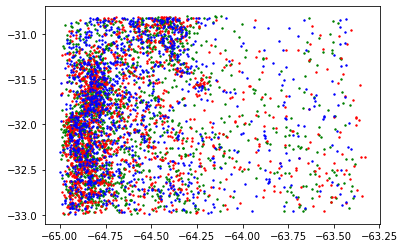

In [28]:
plt.scatter(ds_d3['meanlon'].mean(dim='times'), ds_d3['meanlat'].mean(dim='times'), s=2, c='g')
plt.scatter(ds_d4['meanlon'].mean(dim='times'), ds_d4['meanlat'].mean(dim='times'), s=2, c='r')
plt.scatter(ds_d2['meanlon'].mean(dim='times'), ds_d2['meanlat'].mean(dim='times'), s=2, c='b')

In [29]:
# minlon_d4 = ds_d4['meanlon'].min().values
# maxlon_d4 = ds_d4['meanlon'].max().values
# minlat_d4 = ds_d4['meanlat'].min().values
# maxlat_d4 = ds_d4['meanlat'].max().values
# print(minlon_d4, maxlon_d4, minlat_d4, maxlat_d4)
# print(lon_range, lat_range)

## Find merge/split track indices

In [30]:
# def find_merge_split_tracks(ds):
#     """
#     Find merge/split track indices.
#     """
#     # non-split tracks
#     idx_nsplit = np.isnan(ds.start_split_cloudnumber.load())
#     # non-merge tracks
#     idx_nmerge = np.isnan(ds.end_merge_cloudnumber.load())
#     # non-merge and non-split tracks
#     idx_nms = np.isnan(ds.start_split_cloudnumber.load()) & np.isnan(ds.end_merge_cloudnumber.load())
#     # merge or split tracks
#     idx_ms = ~np.isnan(ds.start_split_cloudnumber.load()) | ~np.isnan(ds.end_merge_cloudnumber.load())
#     # Group outputs to dictionary
#     out_dict = {
#         'ms': idx_ms,
#         'nms': idx_nms,
#         'nm': idx_nmerge,
#         'ns': idx_nsplit,
#     }
#     return out_dict

In [31]:
def find_merge_split_tracks(ds, time_window, time_res=5.0):
    """
    Find merge/split track indices.

    Args:
        ds: Xarray DataSet
            DataSet for cell tracks.
        time_window: array-like
            Time window to constrain mergers [minutes].
        time_res: float, default=5.0
            Time resolution of the tracking data [minutes].

    Return:
        out_dict: dictionary
            Dictionary containing various sets of track indices.
    """
    # Get track lifetime
    lifetime = ds.track_duration.load() * time_res

    # Non-split tracks
    idx_nsplit = np.isnan(ds.start_split_cloudnumber.load())

    # Non-merge tracks
    idx_nmerge = np.isnan(ds.end_merge_cloudnumber.load())

    # Merge after time window tracks
    idx_merge_after = ~np.isnan(ds.end_merge_cloudnumber.load()) & (lifetime > np.max(time_window))

    # Combine conditions (satisfy both):
    # - Non-merge or merge after time window
    # - Non-split
    idx_nms = np.logical_and(idx_nsplit, (np.logical_or(idx_nmerge, idx_merge_after)))

    # Group outputs to dictionary
    out_dict = {
        'ns': idx_nsplit,
        'nm': idx_nmerge,
        'ms': idx_merge_after,
        'nms': idx_nms,
    }
    return out_dict

## Subset DataSets with non-merge/non-split tracks

In [32]:
# time_window = (ds_d2.attrs['time_start'], ds_d2.attrs['time_end'])
# time_window is in Wmask files
time_window = (0, 60)  # [min]

tid_d2 = find_merge_split_tracks(ds_d2, time_window)
tid_d3 = find_merge_split_tracks(ds_d3, time_window)
tid_d4 = find_merge_split_tracks(ds_d4, time_window)

In [33]:
# Get number of tracks
ntracks_d2 = ds_d2.sizes['tracks']
ntracks_d3 = ds_d3.sizes['tracks']
ntracks_d4 = ds_d4.sizes['tracks']
print(f'D2 all tracks: {ntracks_d2}')
print(f'D3 all tracks: {ntracks_d3}')
print(f'D4 all tracks: {ntracks_d4}')

D2 all tracks: 1228
D3 all tracks: 1748
D4 all tracks: 1442


In [35]:
dsnms_d2 = ds_d2.isel(tracks=tid_d2['nms'])
dsnms_d3 = ds_d3.isel(tracks=tid_d3['nms'])
dsnms_d4 = ds_d4.isel(tracks=tid_d4['nms'])

# Get number of tracks
ntracks_nms_d2 = dsnms_d2.sizes['tracks']
ntracks_nms_d3 = dsnms_d3.sizes['tracks']
ntracks_nms_d4 = dsnms_d4.sizes['tracks']
print(f'D2 non-merge-split tracks: {ntracks_nms_d2} ({100*ntracks_nms_d2/ntracks_d2:.0f}% of all tracks)')
print(f'D3 non-merge-split tracks: {ntracks_nms_d3} ({100*ntracks_nms_d3/ntracks_d3:.0f}% of all tracks)')
print(f'D4 non-merge-split tracks: {ntracks_nms_d4} ({100*ntracks_nms_d4/ntracks_d4:.0f}% of all tracks)')

In [36]:
# Get some constents common for all Datasets
ntimes = dsnms_d2.sizes['times']
# nz = dsnms_d2.sizes['z']
time_coord = dsnms_d2.times
xtime = time_coord * time_res  # [min]

In [37]:
# Find time coordinate index of the time_window
tidx_start = np.abs(xtime - np.min(time_window)).argmin().item()
tidx_end = np.abs(xtime - np.max(time_window)).argmin().item()
tidx_start, tidx_end

(0, 12)

## Subset cell area/ETH stats to **CI time window** and get their CI-period max values

In [38]:
# Subset DataSet to CI time_window
dsCI_d2 = dsnms_d2.isel(times=slice(tidx_start, tidx_end))
dsCI_d3 = dsnms_d3.isel(times=slice(tidx_start, tidx_end))
dsCI_d4 = dsnms_d4.isel(times=slice(tidx_start, tidx_end))

# Cell max reflectivity
maxdbz_d2 = dsCI_d2['max_dbz'].load()
maxdbz_d3 = dsCI_d3['max_dbz'].load()
maxdbz_d4 = dsCI_d4['max_dbz'].load()
# Cell ETH
maxETH_10dbz_d2 = dsCI_d2['maxETH_10dbz'].load()
maxETH_10dbz_d3 = dsCI_d3['maxETH_10dbz'].load()
maxETH_10dbz_d4 = dsCI_d4['maxETH_10dbz'].load()
# Cell diameter
cellarea_d2 = dsCI_d2['cell_area'].load()
cellarea_d3 = dsCI_d3['cell_area'].load()
cellarea_d4 = dsCI_d4['cell_area'].load()
celldiam_d2 = 2 * np.sqrt(cellarea_d2 / np.pi)
celldiam_d3 = 2 * np.sqrt(cellarea_d3 / np.pi)
celldiam_d4 = 2 * np.sqrt(cellarea_d4 / np.pi)

## Get **CI-max** 10dBZ ETH and cell diameter percentile values

In [39]:
trackmaxETH_10dbz_d2 = maxETH_10dbz_d2.max(dim='times')
trackmaxCellDiam_d2 = celldiam_d2.max(dim='times')

trackmaxETH_10dbz_d3 = maxETH_10dbz_d3.max(dim='times')
trackmaxCellDiam_d3 = celldiam_d3.max(dim='times')

trackmaxETH_10dbz_d4 = maxETH_10dbz_d4.max(dim='times')
trackmaxCellDiam_d4 = celldiam_d4.max(dim='times')

In [40]:
# Add CI-period variables to DataSet
dsnms_d2['CImaxCellDiam'] = trackmaxCellDiam_d2
dsnms_d2['CImaxETH_10dbz'] = trackmaxETH_10dbz_d2

# Add CI-period variables to DataSet
dsnms_d3['CImaxCellDiam'] = trackmaxCellDiam_d3
dsnms_d3['CImaxETH_10dbz'] = trackmaxETH_10dbz_d3

# Add CI-period variables to DataSet
dsnms_d4['CImaxCellDiam'] = trackmaxCellDiam_d4
dsnms_d4['CImaxETH_10dbz'] = trackmaxETH_10dbz_d4

In [41]:
# # Get cell track lifetime: track_duration x time_resolution [min]
# track_lifetime_d2 = dsnms_d2['track_duration'].load() * time_res
# track_lifetime_d3 = dsnms_d3['track_duration'].load() * time_res
# track_lifetime_d4 = dsnms_d4['track_duration'].load() * time_res

# # Cell max reflectivity
# maxdbz_d2 = dsnms_d2['max_dbz'].load()
# maxdbz_d3 = dsnms_d3['max_dbz'].load()
# maxdbz_d4 = dsnms_d4['max_dbz'].load()
# # Cell ETH
# maxETH_10dbz_d2 = dsnms_d2['maxETH_10dbz'].load()
# maxETH_10dbz_d3 = dsnms_d3['maxETH_10dbz'].load()
# maxETH_10dbz_d4 = dsnms_d4['maxETH_10dbz'].load()
# # Cell diameter
# cellarea_d2 = dsnms_d2['cell_area'].load()
# cellarea_d3 = dsnms_d3['cell_area'].load()
# cellarea_d4 = dsnms_d4['cell_area'].load()
# celldiam_d2 = 2 * np.sqrt(cellarea_d2 / np.pi)
# celldiam_d3 = 2 * np.sqrt(cellarea_d3 / np.pi)
# celldiam_d4 = 2 * np.sqrt(cellarea_d4 / np.pi)

In [42]:
# # Get preCI MU LNB
# # preCI_time = -3  # preCI time
# # Select preCI time, the drop the times coordinate (this avoids conflict with cell lifetime-max variables that has no times coordinate)
# MULNB_d2 = (dsnms_d2.EL_height_mu.sel(times=preCI_time)/1000).reset_coords('times', drop=True)
# MULNB_d3 = (dsnms_d3.EL_height_mu.sel(times=preCI_time)/1000).reset_coords('times', drop=True)
# MULNB_d4 = (dsnms_d4.EL_height_mu.sel(times=preCI_time)/1000).reset_coords('times', drop=True)

In [43]:
# Add surface elevation to convert LNB from HAMSL to HAGL
# MULNB_d2 = ((dsnms_d2.EL_height_mu + dsnms_d2.Z_surface)/1000)
# MULNB_d3 = ((dsnms_d3.EL_height_mu + dsnms_d3.Z_surface)/1000)
# MULNB_d4 = ((dsnms_d4.EL_height_mu + dsnms_d4.Z_surface)/1000)
MULNB_d2 = ((dsnms_d2.EL_height_mu)/1000)
MULNB_d3 = ((dsnms_d3.EL_height_mu)/1000)
MULNB_d4 = ((dsnms_d4.EL_height_mu)/1000)

(array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.00195503, 0.00195503, 0.        , 0.00195503,
        0.0058651 , 0.        , 0.00195503, 0.00977517, 0.09970674,
        0.17399804, 0.17790811, 0.17790811, 0.12316716, 0.05669599,
        0.02541544, 0.04496579, 0.07038123, 0.08993157, 0.13098729,
        0.16813294, 0.12903226, 0.15249267, 0.14076246, 0.07624633,
        0.0801564 , 0.05865103]),
 array([ 0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
         5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5,
        11. , 11.5, 12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15.5, 16. ]),
 <BarContainer object of 32 artists>)

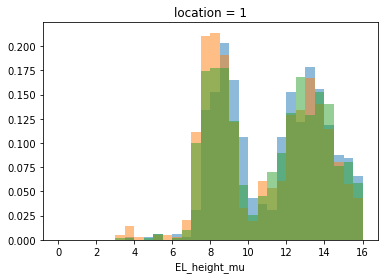

In [44]:
bins = np.arange(0, 16.1, 0.5)
MULNB_d2.plot.hist(bins=bins, alpha=0.5, label='D2', density=True)
MULNB_d3.plot.hist(bins=bins, alpha=0.5, label='D3', density=True)
MULNB_d4.plot.hist(bins=bins, alpha=0.5, label='D4', density=True)

In [45]:
dsnms_d4.where(dsnms_d4.case == '20190123.gefs18', drop=True)

<xarray.Dataset> Size: 2kB
Dimensions:                  (tracks: 0, times: 200, z: 40)
Coordinates:
  * tracks                   (tracks) int64 0B 
  * times                    (times) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
    location                 int64 8B 1
  * z                        (z) float64 320B 250.0 500.0 ... 2e+04 2.1e+04
Data variables: (12/185)
    conv_core                (tracks) float32 0B 
    conv_mask                (tracks) float32 0B 
    dbz_comp                 (tracks) float32 0B 
    echotop10                (tracks) float32 0B 
    LWP                      (tracks) float32 0B 
    IWP                      (tracks) float32 0B 
    ...                       ...
    end_merge_tracknumber    (tracks) float64 0B 
    end_merge_timeindex      (tracks) float64 0B 
    end_merge_cloudnumber    (tracks) float64 0B 
    case                     (tracks) object 0B 
    CImaxCellDiam            (tracks) float32 0B 
    CImaxETH_10dbz           (tracks) float32 0B 
Attributes: (12/14)
    title:                 Tracked cell updraft core masks & statistics
    source_trackfile:      /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    source_W_file:         /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    source_env_file:       /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    time_start:            0
    time_end:              60
    ...                    ...
    cbase_depth:           0.5
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

## Get lifetime-max cell diameter percentile values

In [46]:
# ETH_percentiles = [0.33, 0.5, 0.66]
# trackmaxETH_10dbz_d2 = maxETH_10dbz_d2.max(dim='times')
# max10dbz_pts_d2 = trackmaxETH_10dbz_d2.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
# print(f"Max 10dBZ percentile values (D2): {max10dbz_pts_d2.values}")

# trackmaxCellDiam_d2 = celldiam_d2.max(dim='times')
# maxCellDiam_pts_d2 = trackmaxCellDiam_d2.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
# print(f"Max CellDiam percentile values (D2): {maxCellDiam_pts_d2.values}")

In [47]:
# trackmaxETH_10dbz_d3 = maxETH_10dbz_d3.max(dim='times')
# max10dbz_pts_d3 = trackmaxETH_10dbz_d3.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
# print(f"Max 10dBZ percentile values (D3): {max10dbz_pts_d3.values}")

# trackmaxCellDiam_d3 = celldiam_d3.max(dim='times')
# maxCellDiam_pts_d3 = trackmaxCellDiam_d3.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
# print(f"Max CellDiam percentile values (D3): {maxCellDiam_pts_d3.values}")

In [48]:
# trackmaxETH_10dbz_d4 = maxETH_10dbz_d4.max(dim='times')
# max10dbz_pts_d4 = trackmaxETH_10dbz_d4.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
# print(f"Max 10dBZ percentile values (D4): {max10dbz_pts_d4.values}")

# trackmaxCellDiam_d4 = celldiam_d4.max(dim='times')
# maxCellDiam_pts_d4 = trackmaxCellDiam_d4.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
# print(f"Max CellDiam percentile values (D4): {maxCellDiam_pts_d4.values}")

In [49]:
# mpl.rcParams['font.size'] = 14
# # mpl.rcParams['font.family'] = 'Helvetica'

# fig, axes = plt.subplots(1, 2, figsize=(12,4), dpi=100)
# lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
# name_map = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}

# ax = axes[0]
# bins = np.arange(2, 31, 1)
# bar_data = [trackmaxCellDiam_d2, trackmaxCellDiam_d3, trackmaxCellDiam_d4]
# bar_labels = list(name_map.values())
# bar_colors = list(lcolors.values())
# ax.hist(bar_data, bins=bins, alpha=1, label=bar_labels, histtype='bar', color=bar_colors, density=True)
# ax.legend()
# # Percentile lines
# ax.axvline(maxCellDiam_pts_d2.sel(quantile=0.33), ls='--', color=lcolors['d2'],)
# ax.axvline(maxCellDiam_pts_d2.sel(quantile=0.66), ls='--', color=lcolors['d2'],)
# ax.axvline(maxCellDiam_pts_d3.sel(quantile=0.33), ls=':', color=lcolors['d3'],)
# ax.axvline(maxCellDiam_pts_d3.sel(quantile=0.66), ls=':', color=lcolors['d3'],)
# ax.axvline(maxCellDiam_pts_d4.sel(quantile=0.33), ls='dashdot', color=lcolors['d4'],)
# ax.axvline(maxCellDiam_pts_d4.sel(quantile=0.66), ls='dashdot', color=lcolors['d4'],)
# ax.set_xlim((2,30))
# ax.set_xlabel('Max Cell Diameter (km)')
# ax.set_ylabel('PDF')
# ax.set_title('Cell Width', loc='left')
# ax.grid(ls=':')

# ax = axes[1]
# bins = np.arange(0, 16, 1)
# bar_data = [trackmaxETH_10dbz_d2, trackmaxETH_10dbz_d3, trackmaxETH_10dbz_d4]
# ax.hist(bar_data, bins=bins, alpha=1, label=bar_labels, histtype='bar', color=bar_colors, density=True)

# # Percentile lines
# ax.axvline(max10dbz_pts_d2.sel(quantile=0.5), ls='--', color=lcolors['d2'],)
# # ax.axvline(max10dbz_pts_d2.sel(quantile=0.66), ls='--', color=lcolors['d2'],)
# ax.axvline(max10dbz_pts_d3.sel(quantile=0.5), ls=':', color=lcolors['d3'],)
# # ax.axvline(max10dbz_pts_d3.sel(quantile=0.66), ls=':', color=lcolors['d3'],)
# ax.axvline(max10dbz_pts_d4.sel(quantile=0.5), ls='dashdot', color=lcolors['d4'],)
# # ax.axvline(max10dbz_pts_d4.sel(quantile=0.66), ls='dashdot', color=lcolors['d4'],)
# ax.legend()
# ax.set_xlim((0,16))
# ax.set_xlabel('Max 10dBZ ETH (km)')
# ax.set_ylabel('PDF')
# ax.set_title('Cell Depth', loc='left')
# ax.grid(ls=':')

# # figname = f'{figdir}PDF_maxCellDiam_maxETH10dBZ_d2_d3_d4.png'
# # fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')

## Separate narrow vs. wide cell DataSets

In [50]:
narrow_diam_d2 = 12.93  # km 
narrow_diam_d3 = 7.05  # km  
narrow_diam_d4 = 7.44  # km

wide_diam_d2 = 15.71  # km
wide_diam_d3 = 9.10  # km
wide_diam_d4 = 8.97  # km

In [53]:
# MU LNB threshold, cells must have LNB > this to be retained in the subsequent analysis
MULNB_thresh = 6.0  # [km]
# Threshold for max distance between updraft base and LCL height [km]
max_Wbase_LCL_dist = 2.0  # [km]
# Threshold for updraft top fit line slope
min_Wtop_slope = 0

In [54]:
# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
narrow_tracks_d2 = ((dsnms_d2.CImaxCellDiam < narrow_diam_d2) & (dsnms_d2.EL_height_mu/1000 > MULNB_thresh) \
                    & (dsnms_d2.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                   ).compute()
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_d2 = ((dsnms_d2.CImaxCellDiam >= wide_diam_d2) & (dsnms_d2.EL_height_mu/1000 > MULNB_thresh) \
                  & (dsnms_d2.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_d2.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                 ).compute()
# Subset DataSets
ds_narrow_d2 = dsnms_d2.where(narrow_tracks_d2, drop=True)
ds_wide_d2 = dsnms_d2.where(wide_tracks_d2, drop=True)
ntracks_narrow_d2 = ds_narrow_d2.sizes['tracks']
ntracks_wide_d2 = ds_wide_d2.sizes['tracks']
print(f'Number of narrow cells (D2): {ntracks_narrow_d2}')
print(f'Number of wide cells (D2): {ntracks_wide_d2}')

Number of narrow cells (D2): 424
Number of wide cells (D2): 84


In [55]:
# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
narrow_tracks_d3 = ((dsnms_d3.CImaxCellDiam < narrow_diam_d3) & (dsnms_d3.EL_height_mu/1000 > MULNB_thresh) \
                    & (dsnms_d3.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                   ).compute()
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_d3 = ((dsnms_d3.CImaxCellDiam >= wide_diam_d3) & (dsnms_d3.EL_height_mu/1000 > MULNB_thresh) \
                  & (dsnms_d3.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_d3.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                 ).compute()
# Subset DataSets
ds_narrow_d3 = dsnms_d3.where(narrow_tracks_d3, drop=True)
ds_wide_d3 = dsnms_d3.where(wide_tracks_d3, drop=True)
ntracks_narrow_d3 = ds_narrow_d3.sizes['tracks']
ntracks_wide_d3 = ds_wide_d3.sizes['tracks']
print(f'Number of narrow cells (D3): {ntracks_narrow_d3}')
print(f'Number of wide cells (D3): {ntracks_wide_d3}')

Number of narrow cells (D3): 713
Number of wide cells (D3): 217


In [56]:
# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
narrow_tracks_d4 = ((dsnms_d4.CImaxCellDiam < narrow_diam_d4) & (dsnms_d4.EL_height_mu/1000 > MULNB_thresh) \
                    & (dsnms_d4.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                   ).compute()
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_d4 = ((dsnms_d4.CImaxCellDiam >= wide_diam_d4) & (dsnms_d4.EL_height_mu/1000 > MULNB_thresh) \
                  & (dsnms_d4.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_d4.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                 ).compute()
# Subset DataSets
ds_narrow_d4 = dsnms_d4.where(narrow_tracks_d4, drop=True)
ds_wide_d4 = dsnms_d4.where(wide_tracks_d4, drop=True)
ntracks_narrow_d4 = ds_narrow_d4.sizes['tracks']
ntracks_wide_d4 = ds_wide_d4.sizes['tracks']
print(f'Number of narrow cells (D4): {ntracks_narrow_d4}')
print(f'Number of wide cells (D4): {ntracks_wide_d4}')

Number of narrow cells (D4): 704
Number of wide cells (D4): 190


In [34]:
# # MU LNB threshold, cells must have LNB > this to be retained in the subsequent analysis
# MULNB_thresh = 6.0  # [km]

In [85]:
# # Define narrow vs. wide thresholds
# narrow_diam_d2 = maxCellDiam_pts_d2.sel(quantile=0.33).item()
# wide_diam_d2 = maxCellDiam_pts_d2.sel(quantile=0.66).item()
# print(f'Narrow diameter threshold (D2): {narrow_diam_d2:.01f} km')
# print(f'Wide diameter threshold (D2): {wide_diam_d2:.01f} km')

# # Separate narrow vs. wide cell DataSets, also require LNB > MULNB_thresh
# narrow_tracks_d2 = ((trackmaxCellDiam_d2 <= narrow_diam_d2) & (MULNB_d2 > MULNB_thresh)).compute()
# wide_tracks_d2 = ((trackmaxCellDiam_d2 >= wide_diam_d2) & (MULNB_d2 > MULNB_thresh)).compute()
# # Subset DataSets
# ds_narrow_d2 = dsnms_d2.where(narrow_tracks_d2, drop=True)
# ds_wide_d2 = dsnms_d2.where(wide_tracks_d2, drop=True)
# ntracks_narrow_d2 = ds_narrow_d2.sizes['tracks']
# ntracks_wide_d2 = ds_wide_d2.sizes['tracks']
# print(f'Number of narrow cells (D2): {ntracks_narrow_d2}')
# print(f'Number of wide cells (D2): {ntracks_wide_d2}')

# # Get cell track lifetime: track_duration x time_resolution [min]
# narrow_track_lifetime_d2 = ds_narrow_d2.track_duration * time_res
# wide_track_lifetime_d2 = ds_wide_d2.track_duration * time_res
# # Lifetime-max reflectivity
# narrow_maxdbz_d2 = ds_narrow_d2.max_dbz.max(dim='times')
# wide_maxdbz_d2 = ds_wide_d2.max_dbz.max(dim='times')
# # Lifetime-max 10dBZ ETH
# narrow_maxETH10dbz_d2 = ds_narrow_d2.maxETH_10dbz.max(dim='times')
# wide_maxETH10dbz_d2 = ds_wide_d2.maxETH_10dbz.max(dim='times')

In [86]:
# # Define narrow vs. wide thresholds
# narrow_diam_d3 = maxCellDiam_pts_d3.sel(quantile=0.33).item()
# wide_diam_d3 = maxCellDiam_pts_d3.sel(quantile=0.66).item()
# print(f'Narrow diameter threshold (D3): {narrow_diam_d3:.01f} km')
# print(f'Wide diameter threshold (D3): {wide_diam_d3:.01f} km')

# # Separate narrow vs. wide cell DataSets, also require LNB > MULNB_thresh
# narrow_tracks_d3 = ((trackmaxCellDiam_d3 <= narrow_diam_d3) & (MULNB_d3 > MULNB_thresh)).compute()
# wide_tracks_d3 = ((trackmaxCellDiam_d3 >= wide_diam_d3) & (MULNB_d3 > MULNB_thresh)).compute()
# # Subset DataSets
# ds_narrow_d3 = dsnms_d3.where(narrow_tracks_d3, drop=True)
# ds_wide_d3 = dsnms_d3.where(wide_tracks_d3, drop=True)
# ntracks_narrow_d3 = ds_narrow_d3.sizes['tracks']
# ntracks_wide_d3 = ds_wide_d3.sizes['tracks']
# print(f'Number of narrow cells (D3): {ntracks_narrow_d3}')
# print(f'Number of wide cells (D3): {ntracks_wide_d3}')

# # Get cell track lifetime: track_duration x time_resolution [min]
# narrow_track_lifetime_d3 = ds_narrow_d3.track_duration * time_res
# wide_track_lifetime_d3 = ds_wide_d3.track_duration * time_res
# # Lifetime-max reflectivity
# narrow_maxdbz_d3 = ds_narrow_d3.max_dbz.max(dim='times')
# wide_maxdbz_d3 = ds_wide_d3.max_dbz.max(dim='times')
# # Lifetime-max 10dBZ ETH
# narrow_maxETH10dbz_d3 = ds_narrow_d3.maxETH_10dbz.max(dim='times')
# wide_maxETH10dbz_d3 = ds_wide_d3.maxETH_10dbz.max(dim='times')

In [87]:
# # Define narrow vs. wide thresholds
# narrow_diam_d4 = maxCellDiam_pts_d4.sel(quantile=0.33).item()
# wide_diam_d4 = maxCellDiam_pts_d4.sel(quantile=0.66).item()
# print(f'Narrow diameter threshold (D4): {narrow_diam_d4:.01f} km')
# print(f'Wide diameter threshold (D4): {wide_diam_d4:.01f} km')

# # Separate narrow vs. wide cell DataSets, also require LNB > MULNB_thresh
# narrow_tracks_d4 = ((trackmaxCellDiam_d4 <= narrow_diam_d4) & (MULNB_d4 > MULNB_thresh)).compute()
# wide_tracks_d4 = ((trackmaxCellDiam_d4 >= wide_diam_d4) & (MULNB_d4 > MULNB_thresh)).compute()
# # Subset DataSets
# ds_narrow_d4 = dsnms_d4.where(narrow_tracks_d4, drop=True)
# ds_wide_d4 = dsnms_d4.where(wide_tracks_d4, drop=True)
# ntracks_narrow_d4 = ds_narrow_d4.sizes['tracks']
# ntracks_wide_d4 = ds_wide_d4.sizes['tracks']
# print(f'Number of narrow cells (D4): {ntracks_narrow_d4}')
# print(f'Number of wide cells (D4): {ntracks_wide_d4}')

# # Get cell track lifetime: track_duration x time_resolution [min]
# narrow_track_lifetime_d4 = ds_narrow_d4.track_duration * time_res
# wide_track_lifetime_d4 = ds_wide_d4.track_duration * time_res
# # Lifetime-max reflectivity
# narrow_maxdbz_d4 = ds_narrow_d4.max_dbz.max(dim='times')
# wide_maxdbz_d4 = ds_wide_d4.max_dbz.max(dim='times')
# # Lifetime-max 10dBZ ETH
# narrow_maxETH10dbz_d4 = ds_narrow_d4.maxETH_10dbz.max(dim='times')
# wide_maxETH10dbz_d4 = ds_wide_d4.maxETH_10dbz.max(dim='times')

(array([3., 8., 5., 7., 5., 1., 7., 3., 5., 3.]),
 array([11.88     , 12.212    , 12.544    , 12.876    , 13.208    ,
        13.54     , 13.872    , 14.2039995, 14.536    , 14.868    ,
        15.2      ], dtype=float32),
 <BarContainer object of 10 artists>)

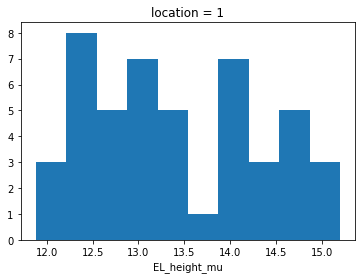

In [89]:
MULNB_d4.where(dsnms_d4.case == '20190123-gefs18', drop=True).plot.hist()

In [57]:
ds_wide_d4.where(ds_wide_d4.case == '20190123-gefs18', drop=True)

<xarray.Dataset> Size: 2MB
Dimensions:                  (tracks: 11, times: 200, z: 40)
Coordinates:
  * tracks                   (tracks) int64 88B 962 968 969 ... 1003 1016 1019
  * times                    (times) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
    location                 int64 8B 1
  * z                        (z) float64 320B 250.0 500.0 ... 2e+04 2.1e+04
Data variables: (12/185)
    conv_core                (tracks) float32 44B 0.0 1.0 0.0 ... 0.0 0.0 0.0
    conv_mask                (tracks) float32 44B 0.0 3.0 0.0 ... 0.0 0.0 0.0
    dbz_comp                 (tracks) float32 44B -35.0 20.13 ... -35.0 -6.516
    echotop10                (tracks) float32 44B nan 2.5e+03 ... nan nan
    LWP                      (tracks) float32 44B 0.0 0.02101 ... 0.0 0.01224
    IWP                      (tracks) float32 44B 0.0 0.0 ... 0.0 0.2137
    ...                       ...
    end_merge_tracknumber    (tracks) float64 88B 259.0 nan 50.0 ... nan nan
    end_merge_timeindex      (tracks) float64 88B 9.0 nan 21.0 ... 24.0 nan nan
    end_merge_cloudnumber    (tracks) float64 88B 4.0 nan 1.0 ... 1.0 nan nan
    case                     (tracks) object 88B '20190123-gefs18' ... '20190...
    CImaxCellDiam            (tracks) float32 44B 14.23 10.46 ... 10.2 12.75
    CImaxETH_10dbz           (tracks) float32 44B 10.0 7.5 9.0 ... 15.0 11.0 9.0
Attributes: (12/14)
    title:                 Tracked cell updraft core masks & statistics
    source_trackfile:      /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    source_W_file:         /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    source_env_file:       /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    time_start:            0
    time_end:              60
    ...                    ...
    cbase_depth:           0.5
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

In [58]:
# Get unique case names
uniq_cases = np.unique(dsnms_d4.case)
uniq_cases

array(['20181129-gefs00', '20181129-gefs03', '20181129-gefs09',
       '20181129-gefs18', '20181204-gefs18', '20181204-gefs19',
       '20181205-gefs01', '20190122-gefs01', '20190122-gefs18',
       '20190123-eda05', '20190123-gefs18', '20190125-eda07',
       '20190125-gefs11', '20190129-eda09', '20190129-gefs11',
       '20190208-eda03', '20190208-eda08'], dtype='<U15')

In [59]:
# Convert case names to upper case
uniq_CASES = [s.upper() for s in uniq_cases]
uniq_CASES

['20181129-GEFS00',
 '20181129-GEFS03',
 '20181129-GEFS09',
 '20181129-GEFS18',
 '20181204-GEFS18',
 '20181204-GEFS19',
 '20181205-GEFS01',
 '20190122-GEFS01',
 '20190122-GEFS18',
 '20190123-EDA05',
 '20190123-GEFS18',
 '20190125-EDA07',
 '20190125-GEFS11',
 '20190129-EDA09',
 '20190129-GEFS11',
 '20190208-EDA03',
 '20190208-EDA08']

In [60]:
ntracks_case_narrow_d2 = []
ntracks_case_narrow_d3 = []
ntracks_case_narrow_d4 = []
for icase in uniq_cases:
    # print(icase)
    ntracks_case_narrow_d2.append(ds_narrow_d2.tracks.where(ds_narrow_d2.case == icase, drop=True).sizes['tracks'])
    ntracks_case_narrow_d3.append(ds_narrow_d3.tracks.where(ds_narrow_d3.case == icase, drop=True).sizes['tracks'])
    ntracks_case_narrow_d4.append(ds_narrow_d4.tracks.where(ds_narrow_d4.case == icase, drop=True).sizes['tracks'])

In [61]:
ntracks_case_wide_d2 = []
ntracks_case_wide_d3 = []
ntracks_case_wide_d4 = []
for icase in uniq_cases:
    # print(icase)
    ntracks_case_wide_d2.append(ds_wide_d2.tracks.where(ds_wide_d2.case == icase, drop=True).sizes['tracks'])
    ntracks_case_wide_d3.append(ds_wide_d3.tracks.where(ds_wide_d3.case == icase, drop=True).sizes['tracks'])
    ntracks_case_wide_d4.append(ds_wide_d4.tracks.where(ds_wide_d4.case == icase, drop=True).sizes['tracks'])

In [62]:
for idate in start_dates:
    print(idate)

20181129
20181204
20181205
20190122
20190123
20190125
20190129
20190208


In [63]:
ntracks_date_narrow_d2 = []
ntracks_date_narrow_d3 = []
ntracks_date_narrow_d4 = []

for idate in start_dates:
    # print(idate)
    ntracks_date_narrow_d2.append(ds_narrow_d2.tracks.where(ds_narrow_d2.start_basetime.dt.strftime('%Y%m%d') == idate, drop=True).sizes['tracks'])
    ntracks_date_narrow_d3.append(ds_narrow_d3.tracks.where(ds_narrow_d3.start_basetime.dt.strftime('%Y%m%d') == idate, drop=True).sizes['tracks'])
    ntracks_date_narrow_d4.append(ds_narrow_d4.tracks.where(ds_narrow_d4.start_basetime.dt.strftime('%Y%m%d') == idate, drop=True).sizes['tracks'])

In [64]:
ntracks_date_wide_d2 = []
ntracks_date_wide_d3 = []
ntracks_date_wide_d4 = []

for idate in start_dates:
    # print(idate)
    ntracks_date_wide_d2.append(ds_wide_d2.tracks.where(ds_wide_d2.start_basetime.dt.strftime('%Y%m%d') == idate, drop=True).sizes['tracks'])
    ntracks_date_wide_d3.append(ds_wide_d3.tracks.where(ds_wide_d3.start_basetime.dt.strftime('%Y%m%d') == idate, drop=True).sizes['tracks'])
    ntracks_date_wide_d4.append(ds_wide_d4.tracks.where(ds_wide_d4.start_basetime.dt.strftime('%Y%m%d') == idate, drop=True).sizes['tracks'])

In [65]:
# plt.bar(uniq_cases, ntracks_case_narrow_d2)
# plt.xticks(rotation=90)

In [91]:
def plot_bars(bar_data, xlabel=None, ylabel=None, title=None, figsize=None, figname=None, bold_xlabel=True, fontsize=None):
    # plt.rcParams['font.family'] = 'DejaVu Serif'
    mpl.rcParams['font.family'] = 'Helvetica'
    mpl.rcParams['font.size'] = fontsize

    x = np.arange(len(xlabel))  # the label locations
    width = 0.2  # the width of the bars
    lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
    name_map = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}

    fig, ax = plt.subplots(figsize=figsize, dpi=100)
    bars2 = ax.bar(x - width, bar_data['d2'], width, label=name_map['d2'], color=lcolors['d2'])
    bars3 = ax.bar(x, bar_data['d3'], width, label=name_map['d3'], color=lcolors['d3'])
    bars4 = ax.bar(x + width, bar_data['d4'], width, label=name_map['d4'], color=lcolors['d4'])

    # Create font properties
    bold_font = FontProperties(weight='bold', family='Helvetica')
    regular_font = FontProperties(weight='normal', family='Helvetica')

    if bold_xlabel:
        # Function to format labels
        def format_label(label):
            parts = label.split('-')
            return f"$\\bf{{{parts[0]}}}$.{parts[1]}"

        # Format xlabels
        formatted_xlabels = [format_label(label) for label in xlabel]
    else:
        formatted_xlabels = xlabel

    # Add some text for labels, title and custom x-axis tick labels, etc.
    # ax.set_xlabel('Cases')
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc='left')
    ax.set_xticks(x)
    ax.set_xticklabels(formatted_xlabels, rotation=30, ha='right')
    ax.grid(ls=':', axis='y')
    ax.legend()

    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

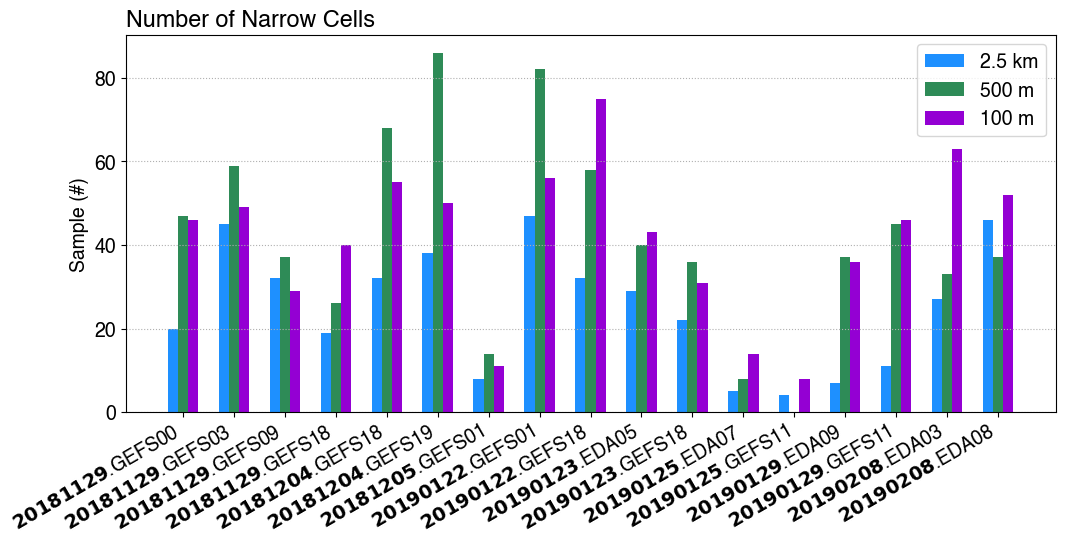

In [92]:
x = np.arange(len(uniq_CASES))
bar_data = {'d2':ntracks_case_narrow_d2, 'd3':ntracks_case_narrow_d3, 'd4':ntracks_case_narrow_d4}
ylabel = 'Sample (#)'
title = 'Number of Narrow Cells'
figsize = [12,5]
fontsize = 14
figname = f'{figdir}CellNumberByCase_narrow_d2_d3_d4.png'
fig = plot_bars(bar_data, xlabel=uniq_CASES, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

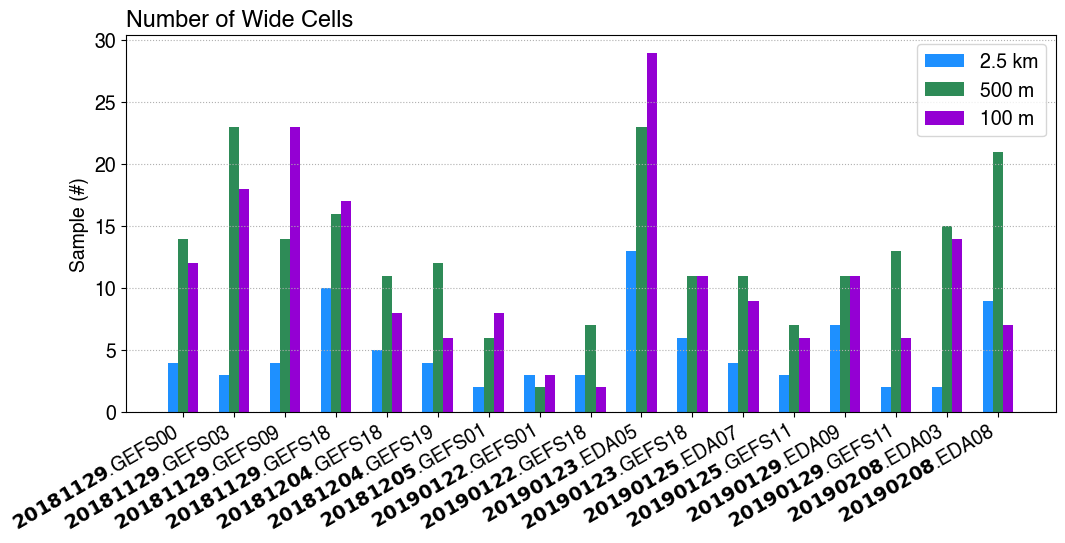

In [93]:
x = np.arange(len(uniq_CASES))
bar_data = {'d2':ntracks_case_wide_d2, 'd3':ntracks_case_wide_d3, 'd4':ntracks_case_wide_d4}
ylabel = 'Sample (#)'
title = 'Number of Wide Cells'
fontsize = 14
figsize = [12,5]
figname = f'{figdir}CellNumberByCase_wide_d2_d3_d4.png'
fig = plot_bars(bar_data, xlabel=uniq_CASES, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

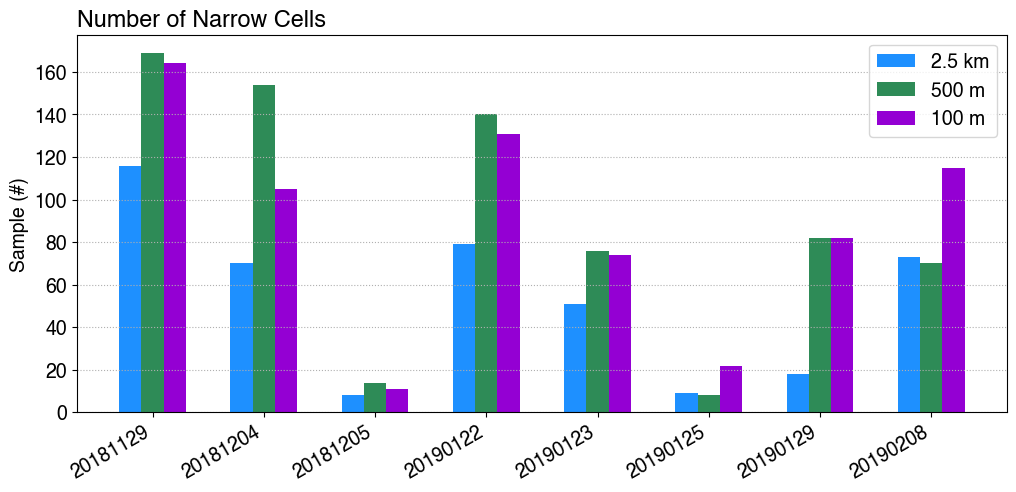

In [94]:
x = np.arange(len(start_dates))
bar_data = {'d2':ntracks_date_narrow_d2, 'd3':ntracks_date_narrow_d3, 'd4':ntracks_date_narrow_d4}
ylabel = 'Sample (#)'
title = 'Number of Narrow Cells'
fontsize = 14
figsize = [12,5]
figname = f'{figdir}CellNumberByDate_narrow_d2_d3_d4.png'
fig = plot_bars(bar_data, xlabel=start_dates, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=False, fontsize=fontsize)

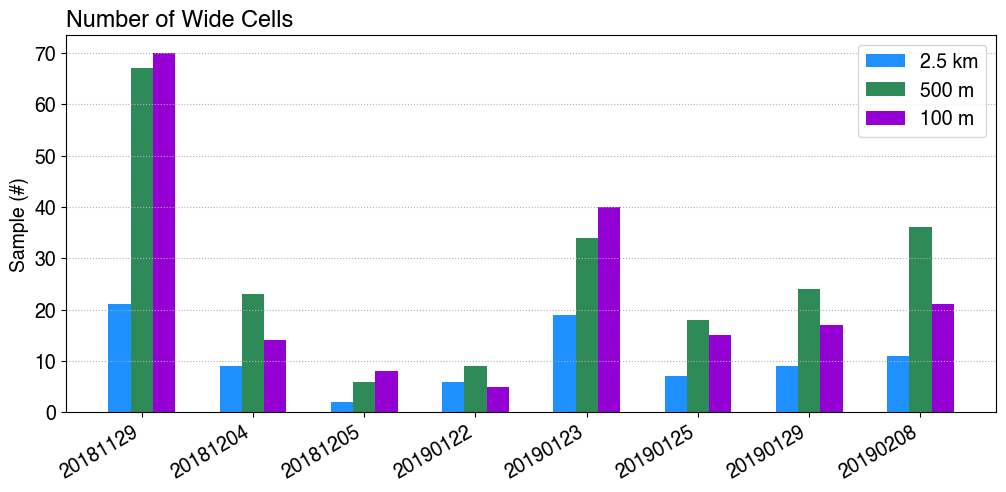

In [95]:
x = np.arange(len(start_dates))
bar_data = {'d2':ntracks_date_wide_d2, 'd3':ntracks_date_wide_d3, 'd4':ntracks_date_wide_d4}
ylabel = 'Sample (#)'
title = 'Number of Wide Cells'
fontsize = 14
figsize = [12,5]
figname = f'{figdir}CellNumberByDate_wide_d2_d3_d4.png'
fig = plot_bars(bar_data, xlabel=start_dates, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=False, fontsize=fontsize)

# Get environmental variables for each date in lists

In [53]:
# def get_var_by_date(ds, varname, preCI_t, scale=1.0):
#     var_out = []
#     for idate in start_dates:
#         var_out.append(ds[varname].where(ds.start_basetime.dt.strftime('%Y%m%d') == idate, drop=True).sel(times=preCI_t).reset_coords('times', drop=True) * scale)
#     return var_out

In [96]:
def get_var_by_date(ds, varname, scale=1.0):
    var_out = []
    for idate in start_dates:
        var_out.append(ds[varname].where(ds.start_basetime.dt.strftime('%Y%m%d') == idate, drop=True) * scale)
    return var_out

In [163]:
# preCI_t = -3  # preCI time to get a single value

pELmu_date_wide_d2 = get_var_by_date(ds_wide_d2, 'pEL_height_mu', scale=1e-3)
pELmu_date_wide_d3 = get_var_by_date(ds_wide_d3, 'pEL_height_mu', scale=1e-3)
pELmu_date_wide_d4 = get_var_by_date(ds_wide_d4, 'pEL_height_mu', scale=1e-3)

pCAPEmu_date_wide_d2 = get_var_by_date(ds_wide_d2, 'pCAPE_mu')
pCAPEmu_date_wide_d3 = get_var_by_date(ds_wide_d3, 'pCAPE_mu')
pCAPEmu_date_wide_d4 = get_var_by_date(ds_wide_d4, 'pCAPE_mu')

pCAPEacbl_date_wide_d2 = get_var_by_date(ds_wide_d2, 'pCAPEacbl_ml')
pCAPEacbl_date_wide_d3 = get_var_by_date(ds_wide_d3, 'pCAPEacbl_ml')
pCAPEacbl_date_wide_d4 = get_var_by_date(ds_wide_d4, 'pCAPEacbl_ml')

pLCLz_date_wide_d2 = get_var_by_date(ds_wide_d2, 'LCL_height_mu', scale=1e-3)
pLCLz_date_wide_d3 = get_var_by_date(ds_wide_d3, 'LCL_height_mu', scale=1e-3)
pLCLz_date_wide_d4 = get_var_by_date(ds_wide_d4, 'LCL_height_mu', scale=1e-3)

pLFCz_date_wide_d2 = get_var_by_date(ds_wide_d2, 'LFC_height_mu', scale=1e-3)
pLFCz_date_wide_d3 = get_var_by_date(ds_wide_d3, 'LFC_height_mu', scale=1e-3)
pLFCz_date_wide_d4 = get_var_by_date(ds_wide_d4, 'LFC_height_mu', scale=1e-3)

# RHacbl_date_wide_d2 = get_var_by_date(ds_wide_d2, 'RH_mean_ACBL')
# RHacbl_date_wide_d3 = get_var_by_date(ds_wide_d3, 'RH_mean_ACBL')
# RHacbl_date_wide_d4 = get_var_by_date(ds_wide_d4, 'RH_mean_ACBL')

# RH500mb_date_wide_d2 = get_var_by_date(ds_wide_d2, 'rh_500mb')
# RH500mb_date_wide_d3 = get_var_by_date(ds_wide_d3, 'rh_500mb')
# RH500mb_date_wide_d4 = get_var_by_date(ds_wide_d4, 'rh_500mb')

RH600mb_date_wide_d2 = get_var_by_date(ds_wide_d2, 'rh_600mb')
RH600mb_date_wide_d3 = get_var_by_date(ds_wide_d3, 'rh_600mb')
RH600mb_date_wide_d4 = get_var_by_date(ds_wide_d4, 'rh_600mb')

RH5km_date_wide_d2 = get_var_by_date(ds_wide_d2, 'rh_5000masl')
RH5km_date_wide_d3 = get_var_by_date(ds_wide_d3, 'rh_5000masl')
RH5km_date_wide_d4 = get_var_by_date(ds_wide_d4, 'rh_5000masl')

RHlfc1500_date_wide_d2 = get_var_by_date(ds_wide_d2, 'rh_at_pmuLFCplus1500m')
RHlfc1500_date_wide_d3 = get_var_by_date(ds_wide_d3, 'rh_at_pmuLFCplus1500m')
RHlfc1500_date_wide_d4 = get_var_by_date(ds_wide_d4, 'rh_at_pmuLFCplus1500m')

PW_date_wide_d2 = get_var_by_date(ds_wide_d2, 'PW')
PW_date_wide_d3 = get_var_by_date(ds_wide_d3, 'PW')
PW_date_wide_d4 = get_var_by_date(ds_wide_d4, 'PW')

BWSacbl_date_wide_d2 = get_var_by_date(ds_wide_d2, 'shear_mag_bulk_ACBL_mu')
BWSacbl_date_wide_d3 = get_var_by_date(ds_wide_d3, 'shear_mag_bulk_ACBL_mu')
BWSacbl_date_wide_d4 = get_var_by_date(ds_wide_d4, 'shear_mag_bulk_ACBL_mu')

BWS03km_date_wide_d2 = get_var_by_date(ds_wide_d2, 'shear_mag_bulk_0to3km')
BWS03km_date_wide_d3 = get_var_by_date(ds_wide_d3, 'shear_mag_bulk_0to3km')
BWS03km_date_wide_d4 = get_var_by_date(ds_wide_d4, 'shear_mag_bulk_0to3km')

BWS06km_date_wide_d2 = get_var_by_date(ds_wide_d2, 'shear_mag_bulk_0to6km')
BWS06km_date_wide_d3 = get_var_by_date(ds_wide_d3, 'shear_mag_bulk_0to6km')
BWS06km_date_wide_d4 = get_var_by_date(ds_wide_d4, 'shear_mag_bulk_0to6km')

In [164]:
pELmu_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'pEL_height_mu', scale=1e-3)
pELmu_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'pEL_height_mu', scale=1e-3)
pELmu_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'pEL_height_mu', scale=1e-3)

pCAPEmu_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'pCAPE_mu')
pCAPEmu_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'pCAPE_mu')
pCAPEmu_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'pCAPE_mu')

pCAPEacbl_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'pCAPEacbl_ml')
pCAPEacbl_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'pCAPEacbl_ml')
pCAPEacbl_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'pCAPEacbl_ml')

pLCLz_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'LCL_height_mu', scale=1e-3)
pLCLz_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'LCL_height_mu', scale=1e-3)
pLCLz_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'LCL_height_mu', scale=1e-3)

pLFCz_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'LFC_height_mu', scale=1e-3)
pLFCz_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'LFC_height_mu', scale=1e-3)
pLFCz_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'LFC_height_mu', scale=1e-3)

# RHacbl_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'RH_mean_ACBL')
# RHacbl_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'RH_mean_ACBL')
# RHacbl_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'RH_mean_ACBL')

# RH500mb_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'rh_500mb')
# RH500mb_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'rh_500mb')
# RH500mb_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'rh_500mb')

RH600mb_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'rh_600mb')
RH600mb_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'rh_600mb')
RH600mb_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'rh_600mb')

RH5km_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'rh_5000masl')
RH5km_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'rh_5000masl')
RH5km_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'rh_5000masl')

RHlfc1500_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'rh_at_pmuLFCplus1500m')
RHlfc1500_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'rh_at_pmuLFCplus1500m')
RHlfc1500_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'rh_at_pmuLFCplus1500m')

PW_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'PW')
PW_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'PW')
PW_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'PW')

BWSacbl_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'shear_mag_bulk_ACBL_mu')
BWSacbl_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'shear_mag_bulk_ACBL_mu')
BWSacbl_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'shear_mag_bulk_ACBL_mu')

BWS03km_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'shear_mag_bulk_0to3km')
BWS03km_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'shear_mag_bulk_0to3km')
BWS03km_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'shear_mag_bulk_0to3km')

BWS06km_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'shear_mag_bulk_0to6km')
BWS06km_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'shear_mag_bulk_0to6km')
BWS06km_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'shear_mag_bulk_0to6km')

# Get environmental variables for each case in lists

In [81]:
# def get_var_by_case(ds, varname, preCI_t, scale=1.0):
#     var_out = []
#     for icase in uniq_cases:
#         # var_out.append(ds[varname].where(ds.case == icase, drop=True).sel(times=preCI_t).reset_coords('times', drop=True) * scale)
#         var_out.append(ds[varname].where(ds.case == icase, drop=True) * scale)
#     return var_out

In [86]:
def get_var_by_case(ds, varname, scale=1.0):
    var_out = []
    for icase in uniq_cases:
        var_out.append(ds[varname].where(ds.case == icase, drop=True) * scale)
    return var_out

In [158]:
pELmu_case_wide_d2 = get_var_by_case(ds_wide_d2, 'pEL_height_mu', scale=1e-3)
pELmu_case_wide_d3 = get_var_by_case(ds_wide_d3, 'pEL_height_mu', scale=1e-3)
pELmu_case_wide_d4 = get_var_by_case(ds_wide_d4, 'pEL_height_mu', scale=1e-3)

pCAPEmu_case_wide_d2 = get_var_by_case(ds_wide_d2, 'pCAPE_mu')
pCAPEmu_case_wide_d3 = get_var_by_case(ds_wide_d3, 'pCAPE_mu')
pCAPEmu_case_wide_d4 = get_var_by_case(ds_wide_d4, 'pCAPE_mu')

pCAPEacbl_case_wide_d2 = get_var_by_case(ds_wide_d2, 'pCAPEacbl_ml')
pCAPEacbl_case_wide_d3 = get_var_by_case(ds_wide_d3, 'pCAPEacbl_ml')
pCAPEacbl_case_wide_d4 = get_var_by_case(ds_wide_d4, 'pCAPEacbl_ml')

pLCLz_case_wide_d2 = get_var_by_case(ds_wide_d2, 'LCL_height_mu', scale=1e-3)
pLCLz_case_wide_d3 = get_var_by_case(ds_wide_d3, 'LCL_height_mu', scale=1e-3)
pLCLz_case_wide_d4 = get_var_by_case(ds_wide_d4, 'LCL_height_mu', scale=1e-3)

pLFCz_case_wide_d2 = get_var_by_case(ds_wide_d2, 'LFC_height_mu', scale=1e-3)
pLFCz_case_wide_d3 = get_var_by_case(ds_wide_d3, 'LFC_height_mu', scale=1e-3)
pLFCz_case_wide_d4 = get_var_by_case(ds_wide_d4, 'LFC_height_mu', scale=1e-3)

# RHacbl_case_wide_d2 = get_var_by_case(ds_wide_d2, 'RH_mean_ACBL')
# RHacbl_case_wide_d3 = get_var_by_case(ds_wide_d3, 'RH_mean_ACBL')
# RHacbl_case_wide_d4 = get_var_by_case(ds_wide_d4, 'RH_mean_ACBL')

# RH500mb_case_wide_d2 = get_var_by_case(ds_wide_d2, 'rh_500mb')
# RH500mb_case_wide_d3 = get_var_by_case(ds_wide_d3, 'rh_500mb')
# RH500mb_case_wide_d4 = get_var_by_case(ds_wide_d4, 'rh_500mb')

RH600mb_case_wide_d2 = get_var_by_case(ds_wide_d2, 'rh_600mb')
RH600mb_case_wide_d3 = get_var_by_case(ds_wide_d3, 'rh_600mb')
RH600mb_case_wide_d4 = get_var_by_case(ds_wide_d4, 'rh_600mb')

RH5km_case_wide_d2 = get_var_by_case(ds_wide_d2, 'rh_5000masl')
RH5km_case_wide_d3 = get_var_by_case(ds_wide_d3, 'rh_5000masl')
RH5km_case_wide_d4 = get_var_by_case(ds_wide_d4, 'rh_5000masl')

RHlfc1500_case_wide_d2 = get_var_by_case(ds_wide_d2, 'rh_at_pmuLFCplus1500m')
RHlfc1500_case_wide_d3 = get_var_by_case(ds_wide_d3, 'rh_at_pmuLFCplus1500m')
RHlfc1500_case_wide_d4 = get_var_by_case(ds_wide_d4, 'rh_at_pmuLFCplus1500m')

PW_case_wide_d2 = get_var_by_case(ds_wide_d2, 'PW')
PW_case_wide_d3 = get_var_by_case(ds_wide_d3, 'PW')
PW_case_wide_d4 = get_var_by_case(ds_wide_d4, 'PW')

BWSacbl_case_wide_d2 = get_var_by_case(ds_wide_d2, 'shear_mag_bulk_ACBL_mu')
BWSacbl_case_wide_d3 = get_var_by_case(ds_wide_d3, 'shear_mag_bulk_ACBL_mu')
BWSacbl_case_wide_d4 = get_var_by_case(ds_wide_d4, 'shear_mag_bulk_ACBL_mu')

BWS03km_case_wide_d2 = get_var_by_case(ds_wide_d2, 'shear_mag_bulk_0to3km')
BWS03km_case_wide_d3 = get_var_by_case(ds_wide_d3, 'shear_mag_bulk_0to3km')
BWS03km_case_wide_d4 = get_var_by_case(ds_wide_d4, 'shear_mag_bulk_0to3km')

BWS06km_case_wide_d2 = get_var_by_case(ds_wide_d2, 'shear_mag_bulk_0to6km')
BWS06km_case_wide_d3 = get_var_by_case(ds_wide_d3, 'shear_mag_bulk_0to6km')
BWS06km_case_wide_d4 = get_var_by_case(ds_wide_d4, 'shear_mag_bulk_0to6km')

In [159]:
pELmu_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'pEL_height_mu', scale=1e-3)
pELmu_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'pEL_height_mu', scale=1e-3)
pELmu_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'pEL_height_mu', scale=1e-3)

pCAPEmu_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'pCAPE_mu')
pCAPEmu_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'pCAPE_mu')
pCAPEmu_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'pCAPE_mu')

pCAPEacbl_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'pCAPEacbl_ml')
pCAPEacbl_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'pCAPEacbl_ml')
pCAPEacbl_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'pCAPEacbl_ml')

pLCLz_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'LCL_height_mu', scale=1e-3)
pLCLz_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'LCL_height_mu', scale=1e-3)
pLCLz_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'LCL_height_mu', scale=1e-3)

pLFCz_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'LFC_height_mu', scale=1e-3)
pLFCz_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'LFC_height_mu', scale=1e-3)
pLFCz_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'LFC_height_mu', scale=1e-3)

# RHacbl_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'RH_mean_ACBL')
# RHacbl_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'RH_mean_ACBL')
# RHacbl_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'RH_mean_ACBL')

# RH500mb_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'rh_500mb')
# RH500mb_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'rh_500mb')
# RH500mb_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'rh_500mb')

RH600mb_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'rh_600mb')
RH600mb_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'rh_600mb')
RH600mb_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'rh_600mb')

RH5km_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'rh_5000masl')
RH5km_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'rh_5000masl')
RH5km_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'rh_5000masl')

RHlfc1500_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'rh_at_pmuLFCplus1500m')
RHlfc1500_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'rh_at_pmuLFCplus1500m')
RHlfc1500_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'rh_at_pmuLFCplus1500m')

PW_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'PW')
PW_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'PW')
PW_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'PW')

BWSacbl_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'shear_mag_bulk_ACBL_mu')
BWSacbl_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'shear_mag_bulk_ACBL_mu')
BWSacbl_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'shear_mag_bulk_ACBL_mu')

BWS03km_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'shear_mag_bulk_0to3km')
BWS03km_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'shear_mag_bulk_0to3km')
BWS03km_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'shear_mag_bulk_0to3km')

BWS06km_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'shear_mag_bulk_0to6km')
BWS06km_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'shear_mag_bulk_0to6km')
BWS06km_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'shear_mag_bulk_0to6km')

## Function to plot box-whisker plots for 3 data sources

In [131]:
def plot_boxplots(data1, data2, data3, xlabel=None, ylabel=None, ylim=None, title=None, figsize=None, figname=None, bold_xlabel=False, fontsize=14):

    mpl.rcParams['font.family'] = 'Helvetica'
    mpl.rcParams['font.size'] = fontsize
    
    showfliers = False

    # Create a figure and axis
    fig, ax = plt.subplots(figsize=figsize, dpi=100)

    x = np.arange(len(xlabel))  # the label locations
    lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
    name_map = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}

    # Create boxplots with adjustable widths and closer spacing within groups
    group_width = 1.0  # width for each group
    box_width = 0.4  # width for each boxplot
    group_spacing = 2  # space between groups

    # Calculate positions for each box plot
    positions1 = [i * group_spacing + 1 - box_width for i in range(len(data1))]
    positions2 = [i * group_spacing + 1 for i in range(len(data2))]
    positions3 = [i * group_spacing + 1 + box_width for i in range(len(data3))]

    boxprops = dict(linewidth=1.5, edgecolor='k')
    # medianprops = dict(linestyle='-', linewidth=2.5, color='red')
    # meanprops = dict(marker='o', markerfacecolor='magenta', markeredgecolor='black')
    medianprops1 = dict(linestyle='-', linewidth=2.5, color='aquamarine')
    medianprops2 = dict(linestyle='-', linewidth=2.5, color='limegreen')
    medianprops3 = dict(linestyle='-', linewidth=2.5, color='magenta')
    meanprops1 = dict(marker='o', markerfacecolor='aquamarine', markeredgecolor='black')
    meanprops2 = dict(marker='o', markerfacecolor='limegreen', markeredgecolor='black')
    meanprops3 = dict(marker='o', markerfacecolor='magenta', markeredgecolor='black')

    box1 = ax.boxplot(data1, positions=positions1, widths=box_width, patch_artist=True, boxprops=boxprops, medianprops=medianprops1, meanprops=meanprops1, showmeans=True, showfliers=showfliers)
    box2 = ax.boxplot(data2, positions=positions2, widths=box_width, patch_artist=True, boxprops=boxprops, medianprops=medianprops2, meanprops=meanprops2, showmeans=True, showfliers=showfliers)
    box3 = ax.boxplot(data3, positions=positions3, widths=box_width, patch_artist=True, boxprops=boxprops, medianprops=medianprops3, meanprops=meanprops3, showmeans=True, showfliers=showfliers)

    # Set the face color for each group
    colors1 = [lcolors['d2']]*len(xlabel)
    colors2 = [lcolors['d3']]*len(xlabel)
    colors3 = [lcolors['d4']]*len(xlabel)

    for patch, color in zip(box1['boxes'], colors1):
        patch.set_facecolor(color)
    for patch, color in zip(box2['boxes'], colors2):
        patch.set_facecolor(color)
    for patch, color in zip(box3['boxes'], colors3):
        patch.set_facecolor(color)

    if bold_xlabel:
        # Function to format labels
        def format_label(label):
            parts = label.split('-')
            return f"$\\bf{{{parts[0]}}}$.{parts[1]}"

        # Format xlabels
        formatted_xlabels = [format_label(label) for label in xlabel]
    else:
        formatted_xlabels = xlabel

    ax.set_xticks([i * group_spacing + 1 for i in range(len(data1))])
    ax.set_xticklabels(formatted_xlabels, rotation=30, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc='left')
    if (ylim is not None): ax.set_ylim(min(ylim), max(ylim))
    ax.grid(ls=':', axis='y')

    # Add legend
    legend_patches = [
        mpl.patches.Patch(facecolor=lcolors['d2'], edgecolor=boxprops['edgecolor'], linewidth=boxprops['linewidth'], label=name_map['d2']),
        mpl.patches.Patch(facecolor=lcolors['d3'], edgecolor=boxprops['edgecolor'], linewidth=boxprops['linewidth'], label=name_map['d3']),
        mpl.patches.Patch(facecolor=lcolors['d4'], edgecolor=boxprops['edgecolor'], linewidth=boxprops['linewidth'], label=name_map['d4']),
    ]
    ax.legend(handles=legend_patches, loc='best')
    
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

## Make plots by date

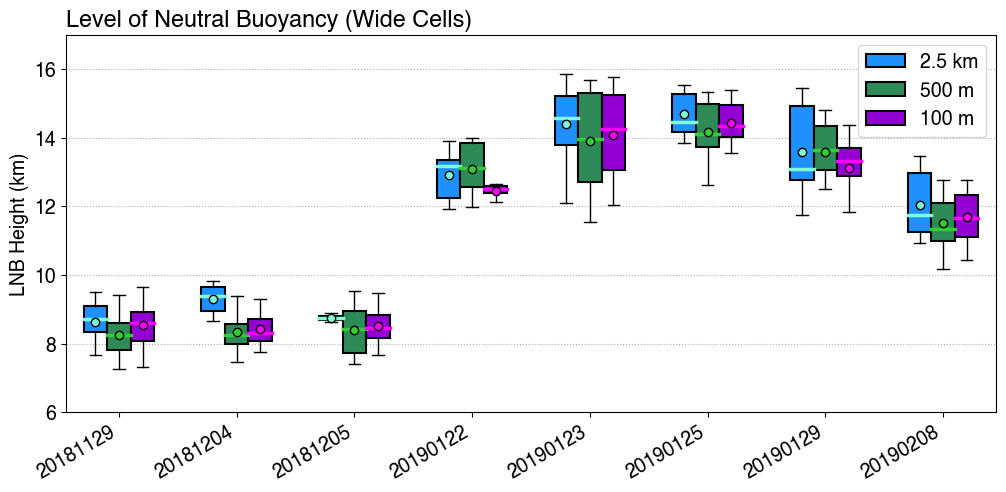

In [100]:
xlabel = start_dates
ylabel = 'LNB Height (km)'
title = 'Level of Neutral Buoyancy (Wide Cells)'
ylim = (6,17)
fontsize = 14
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_pELmu_wide_d2_d3_d4.png'
fig = plot_boxplots(pELmu_date_wide_d2, pELmu_date_wide_d3, pELmu_date_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

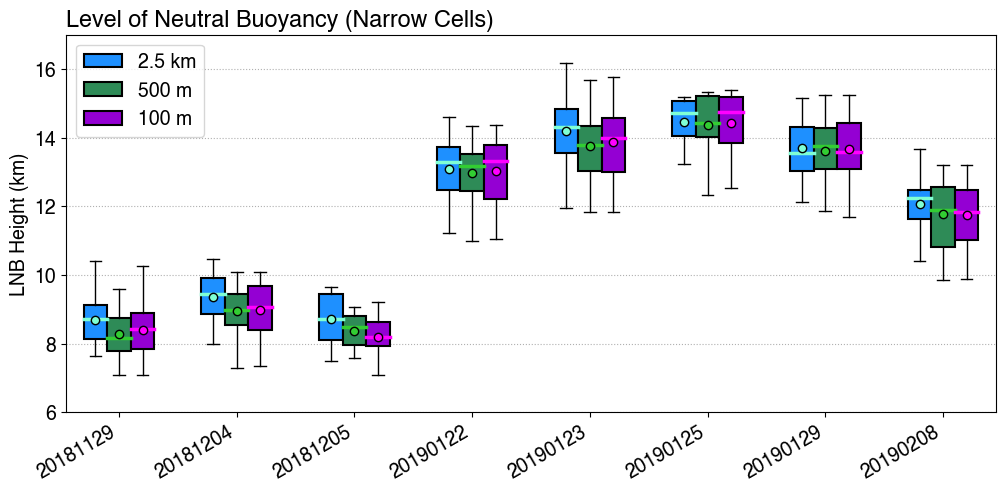

In [101]:
xlabel = start_dates
ylabel = 'LNB Height (km)'
title = 'Level of Neutral Buoyancy (Narrow Cells)'
ylim = (6,17)
fontsize = 14
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_pELmu_narrow_d2_d3_d4.png'
fig = plot_boxplots(pELmu_date_narrow_d2, pELmu_date_narrow_d3, pELmu_date_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

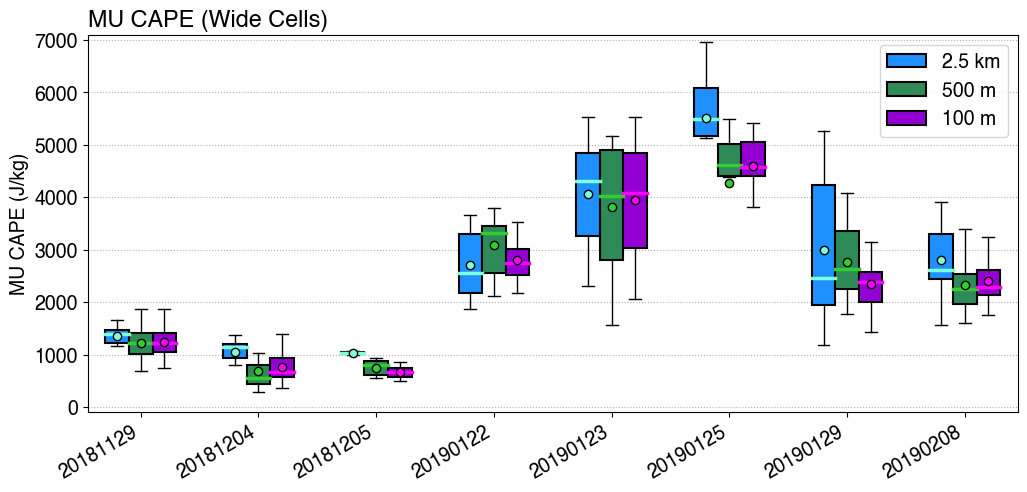

In [102]:
xlabel = start_dates
ylabel = 'MU CAPE (J/kg)'
title = 'MU CAPE (Wide Cells)'
ylim = (-100,7100)
fontsize = 14
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_pCAPEmu_wide_d2_d3_d4.png'
fig = plot_boxplots(pCAPEmu_date_wide_d2, pCAPEmu_date_wide_d3, pCAPEmu_date_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

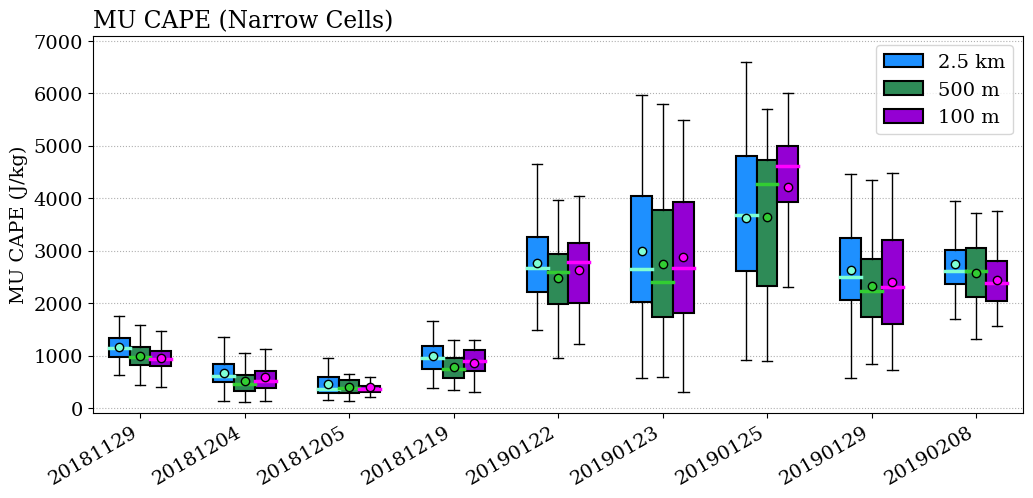

In [64]:
xlabel = start_dates
ylabel = 'MU CAPE (J/kg)'
title = 'MU CAPE (Narrow Cells)'
ylim = (-100,7100)
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_pCAPEmu_narrow_d2_d3_d4.png'
fig = plot_boxplots(pCAPEmu_date_narrow_d2, pCAPEmu_date_narrow_d3, pCAPEmu_date_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

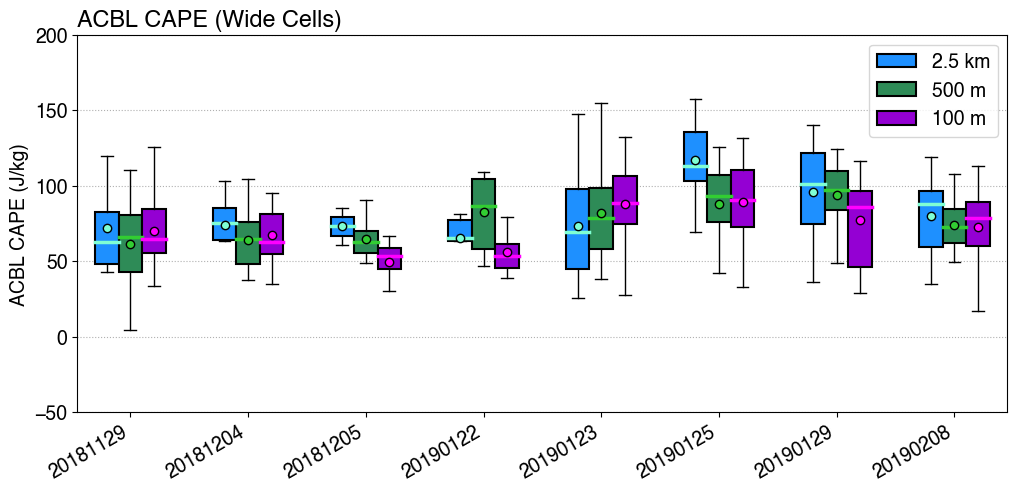

In [106]:
xlabel = start_dates
ylabel = 'ACBL CAPE (J/kg)'
title = 'ACBL CAPE (Wide Cells)'
ylim = (-50,200)
fontsize = 14
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_pCAPEacbl_wide_d2_d3_d4.png'
fig = plot_boxplots(pCAPEacbl_date_wide_d2, pCAPEacbl_date_wide_d3, pCAPEacbl_date_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

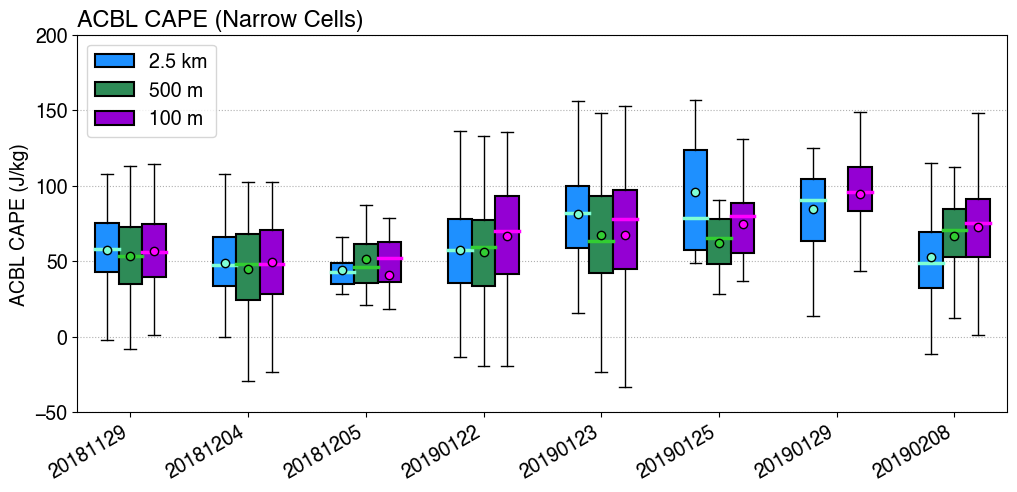

In [107]:
xlabel = start_dates
ylabel = 'ACBL CAPE (J/kg)'
title = 'ACBL CAPE (Narrow Cells)'
ylim = (-50,200)
fontsize = 14
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_pCAPEacbl_narrow_d2_d3_d4.png'
fig = plot_boxplots(pCAPEacbl_date_narrow_d2, pCAPEacbl_date_narrow_d3, pCAPEacbl_date_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

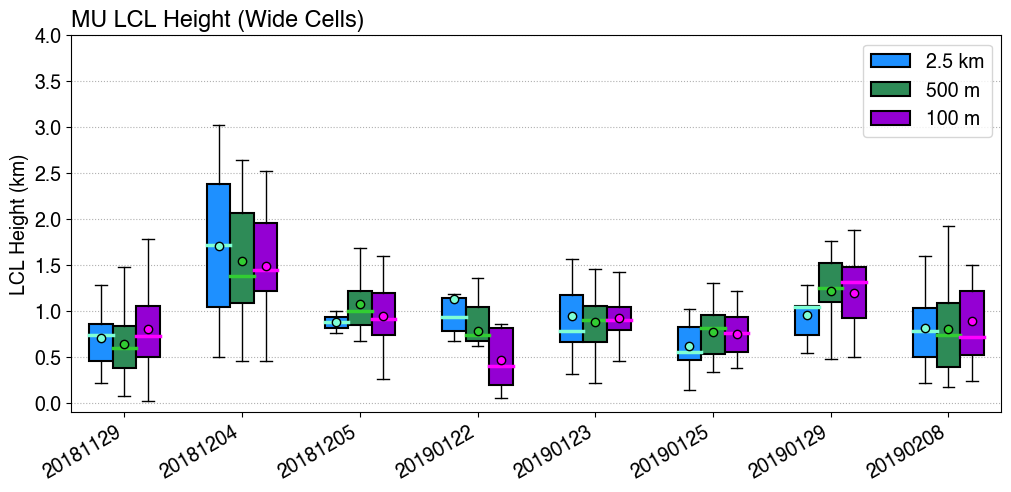

In [108]:
xlabel = start_dates
ylabel = 'LCL Height (km)'
title = 'MU LCL Height (Wide Cells)'
ylim = (-0.1,4)
fontsize = 14
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_pLCLmu_wide_d2_d3_d4.png'
fig = plot_boxplots(pLCLz_date_wide_d2, pLCLz_date_wide_d3, pLCLz_date_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

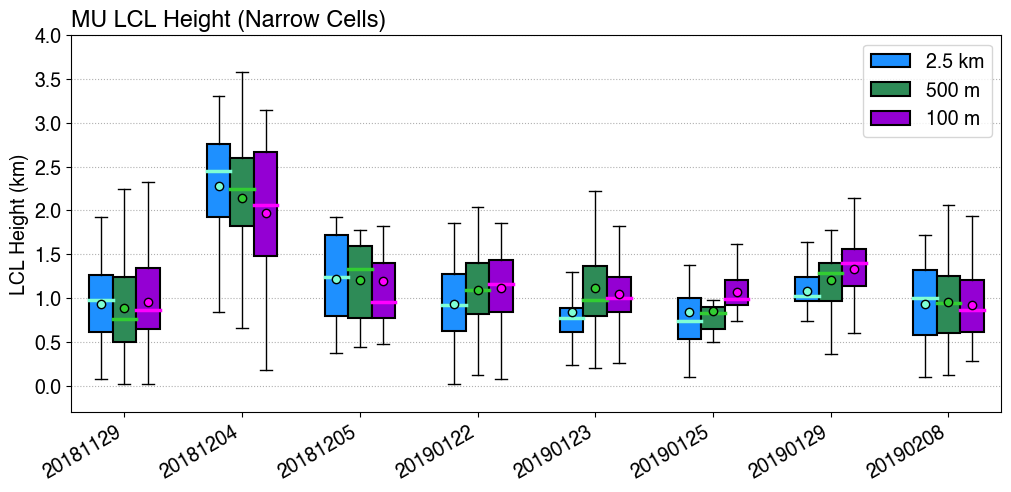

In [109]:
xlabel = start_dates
ylabel = 'LCL Height (km)'
title = 'MU LCL Height (Narrow Cells)'
ylim = (-0.3,4)
fontsize = 14
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_pLCLmu_narrow_d2_d3_d4.png'
fig = plot_boxplots(pLCLz_date_narrow_d2, pLCLz_date_narrow_d3, pLCLz_date_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

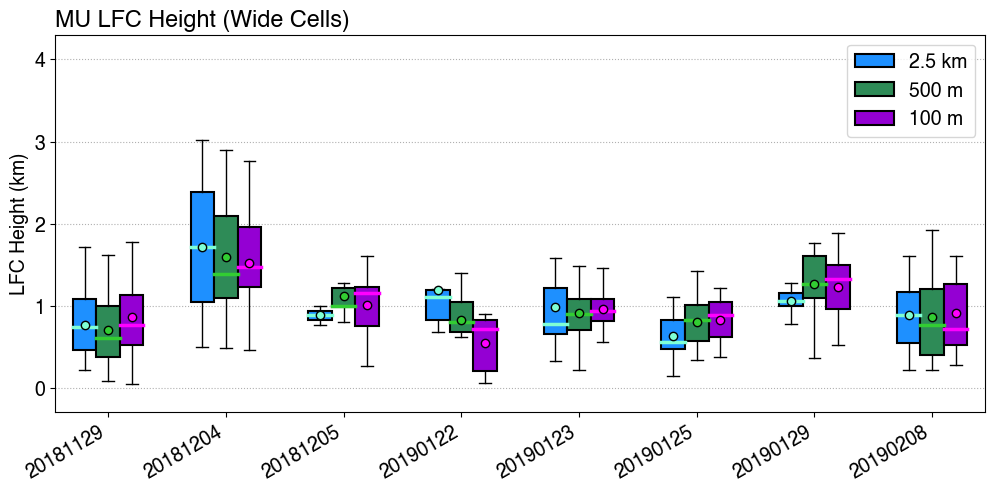

In [110]:
xlabel = start_dates
ylabel = 'LFC Height (km)'
title = 'MU LFC Height (Wide Cells)'
ylim = (-0.3,4.3)
fontsize = 14
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_pLFCmu_wide_d2_d3_d4.png'
fig = plot_boxplots(pLFCz_date_wide_d2, pLFCz_date_wide_d3, pLFCz_date_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

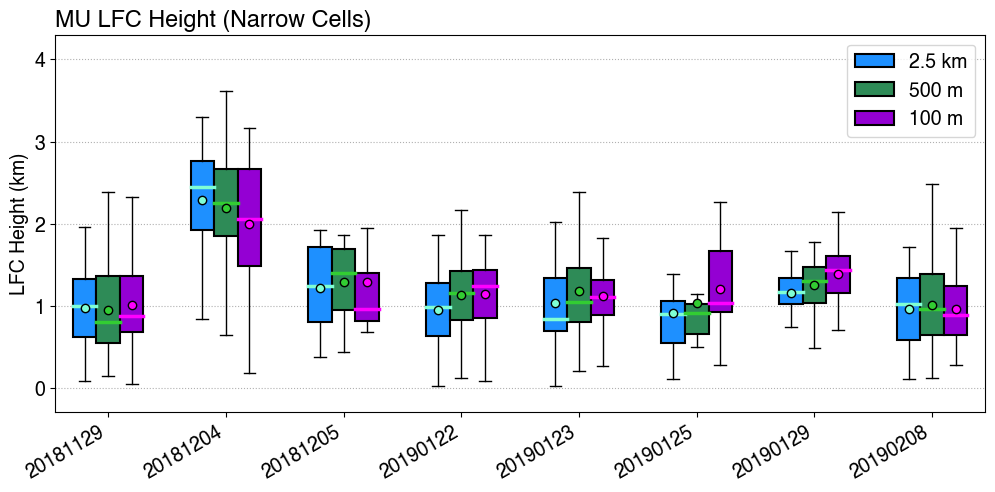

In [111]:
xlabel = start_dates
ylabel = 'LFC Height (km)'
title = 'MU LFC Height (Narrow Cells)'
ylim = (-0.3,4.3)
fontsize = 14
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_pLFCmu_narrow_d2_d3_d4.png'
fig = plot_boxplots(pLFCz_date_narrow_d2, pLFCz_date_narrow_d3, pLFCz_date_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

In [160]:
# xlabel = start_dates
# ylabel = 'RH (%)'
# title = 'ACBL RH (Wide Cells)'
# ylim = (10,102)
# fontsize = 14
# figsize = [12,5]
# figname = f'{figdir}BoxplotByDate_RHacbl_wide_d2_d3_d4.png'
# fig = plot_boxplots(RHacbl_date_wide_d2, RHacbl_date_wide_d3, RHacbl_date_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

In [161]:
# xlabel = start_dates
# ylabel = 'RH (%)'
# title = 'ACBL RH (Narrow Cells)'
# ylim = (10,102)
# fontsize = 14
# figsize = [12,5]
# figname = f'{figdir}BoxplotByDate_RHacbl_narrow_d2_d3_d4.png'
# fig = plot_boxplots(RHacbl_date_narrow_d2, RHacbl_date_narrow_d3, RHacbl_date_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

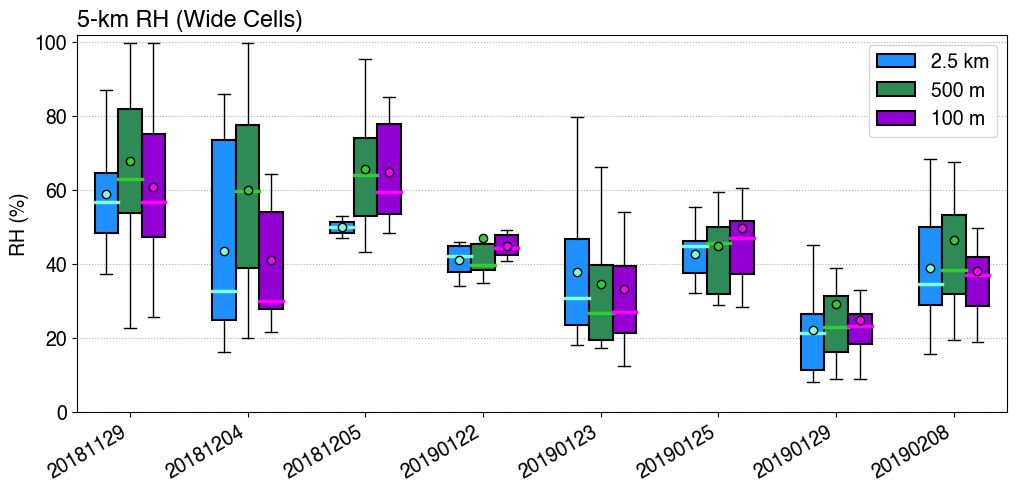

In [114]:
xlabel = start_dates
ylabel = 'RH (%)'
title = '5-km RH (Wide Cells)'
ylim = (0,102)
fontsize = 14
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_RH5km_wide_d2_d3_d4.png'
fig = plot_boxplots(RH5km_date_wide_d2, RH5km_date_wide_d3, RH5km_date_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

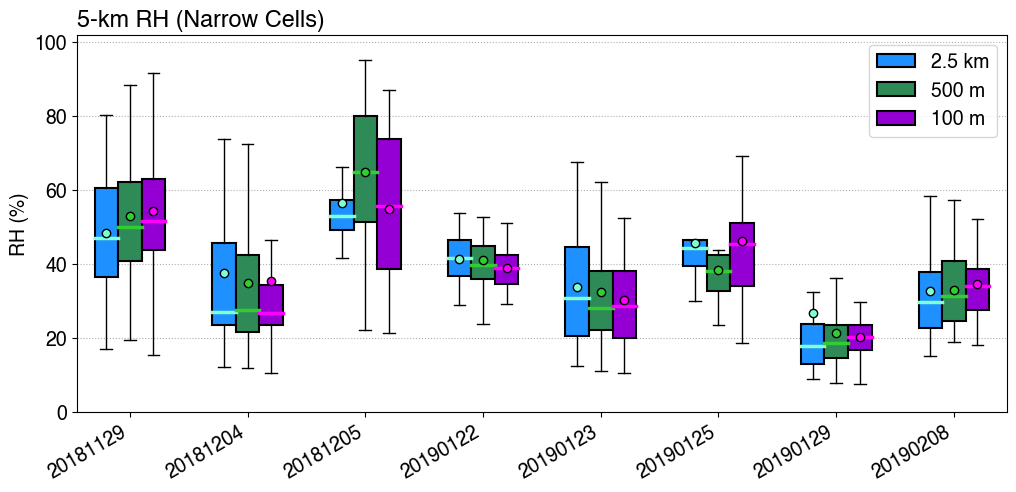

In [116]:
xlabel = start_dates
ylabel = 'RH (%)'
title = '5-km RH (Narrow Cells)'
ylim = (0,102)
fontsize = 14
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_RH5km_narrow_d2_d3_d4.png'
fig = plot_boxplots(RH5km_date_narrow_d2, RH5km_date_narrow_d3, RH5km_date_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

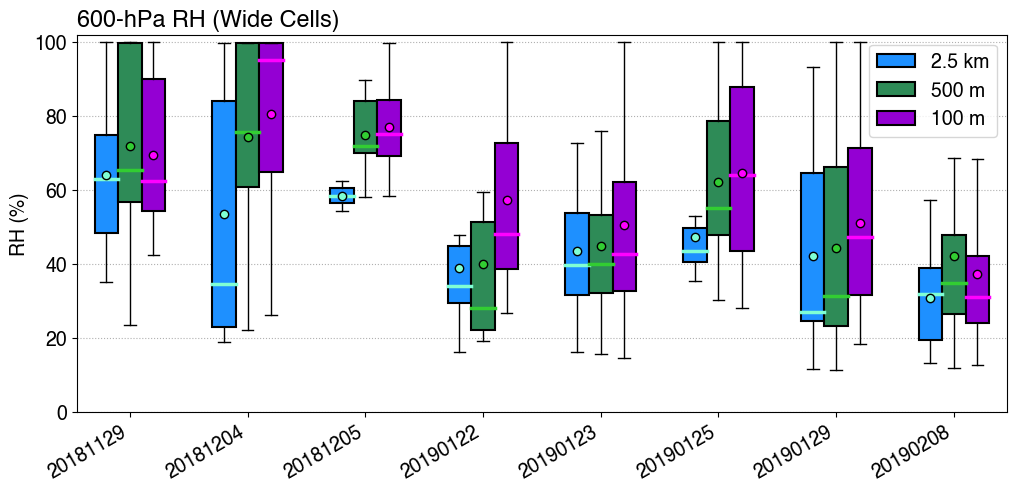

In [165]:
xlabel = start_dates
ylabel = 'RH (%)'
title = '600-hPa RH (Wide Cells)'
ylim = (0,102)
fontsize = 14
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_RH600mb_wide_d2_d3_d4.png'
fig = plot_boxplots(RH600mb_date_wide_d2, RH600mb_date_wide_d3, RH600mb_date_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

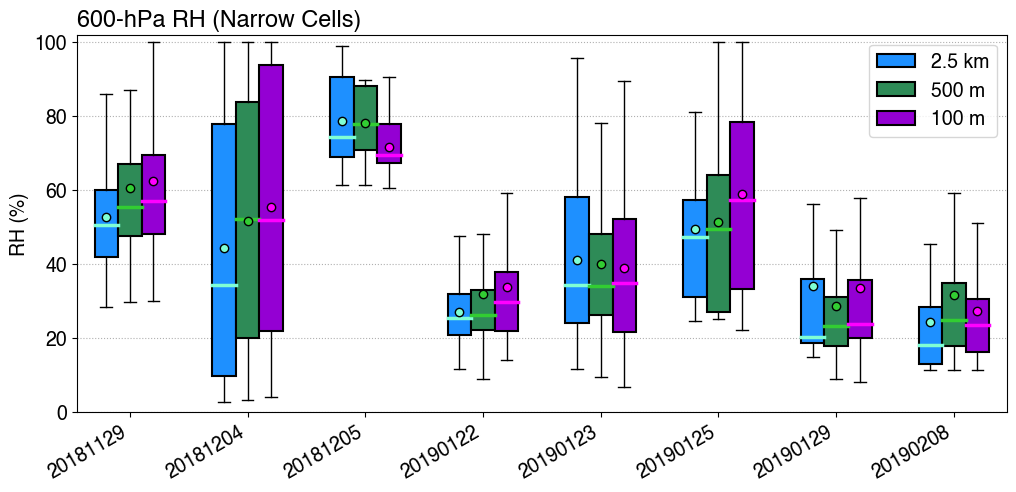

In [166]:
xlabel = start_dates
ylabel = 'RH (%)'
title = '600-hPa RH (Narrow Cells)'
ylim = (0,102)
fontsize = 14
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_RH600mb_narrow_d2_d3_d4.png'
fig = plot_boxplots(RH600mb_date_narrow_d2, RH600mb_date_narrow_d3, RH600mb_date_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

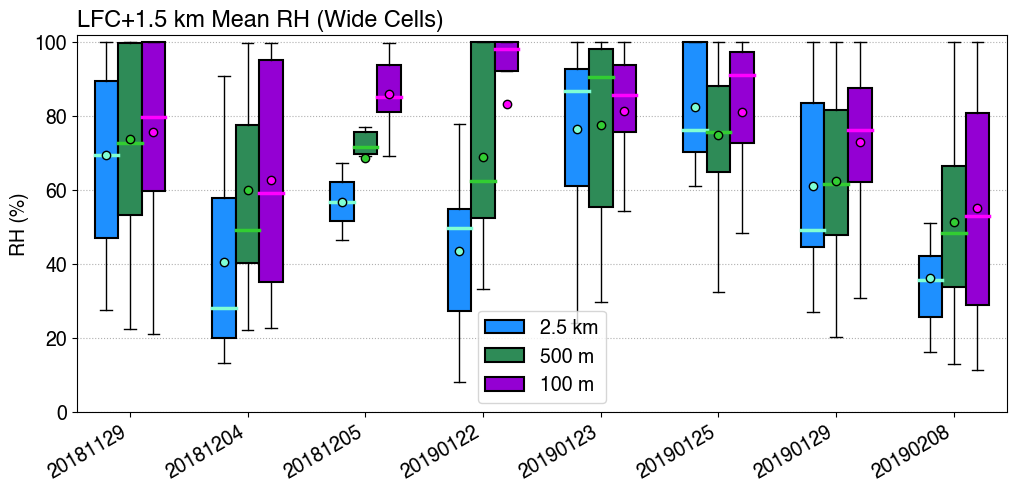

In [119]:
xlabel = start_dates
ylabel = 'RH (%)'
title = 'LFC+1.5 km Mean RH (Wide Cells)'
ylim = (0,102)
fontsize = 14
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_RHlfc1500m_wide_d2_d3_d4.png'
fig = plot_boxplots(RHlfc1500_date_wide_d2, RHlfc1500_date_wide_d3, RHlfc1500_date_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

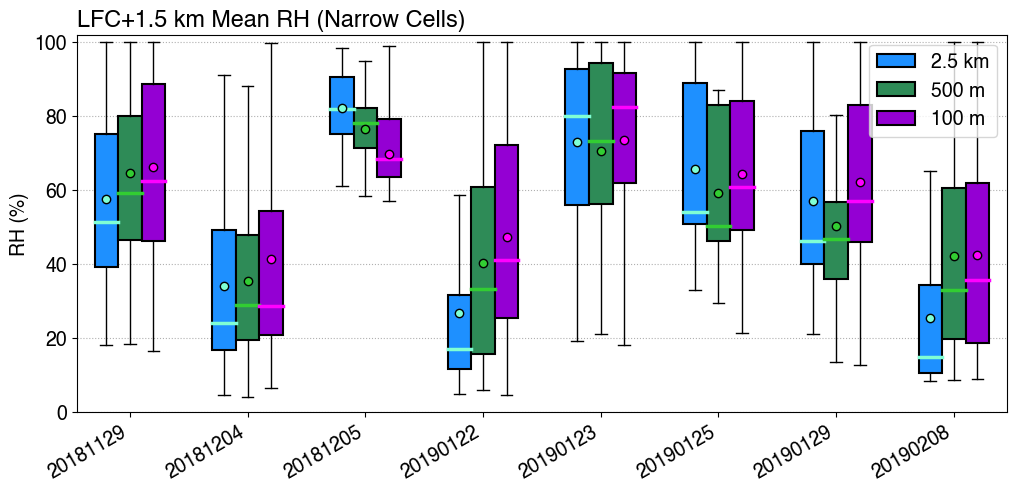

In [120]:
xlabel = start_dates
ylabel = 'RH (%)'
title = 'LFC+1.5 km Mean RH (Narrow Cells)'
ylim = (0,102)
fontsize = 14
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_RHlfc1500m_narrow_d2_d3_d4.png'
fig = plot_boxplots(RHlfc1500_date_narrow_d2, RHlfc1500_date_narrow_d3, RHlfc1500_date_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

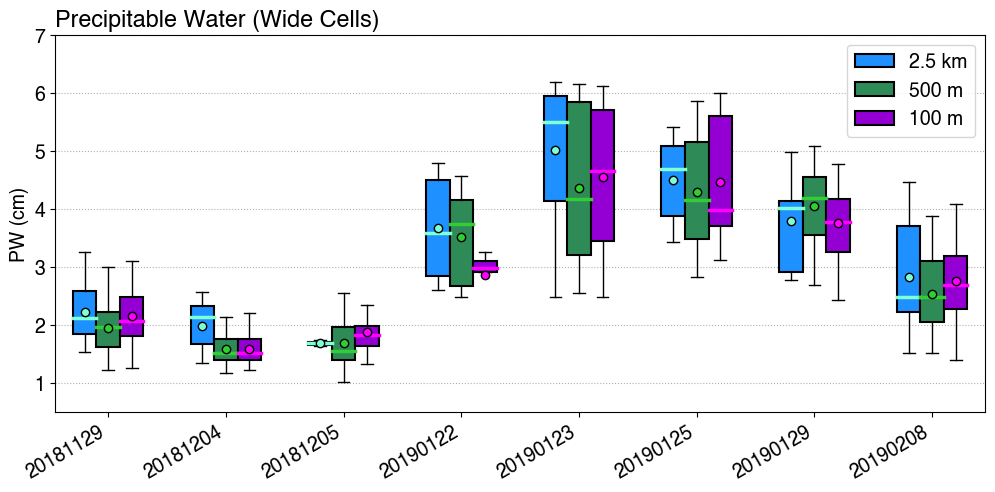

In [121]:
xlabel = start_dates
ylabel = 'PW (cm)'
title = 'Precipitable Water (Wide Cells)'
ylim = (0.5,7)
fontsize = 14
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_PW_wide_d2_d3_d4.png'
fig = plot_boxplots(PW_date_wide_d2, PW_date_wide_d3, PW_date_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

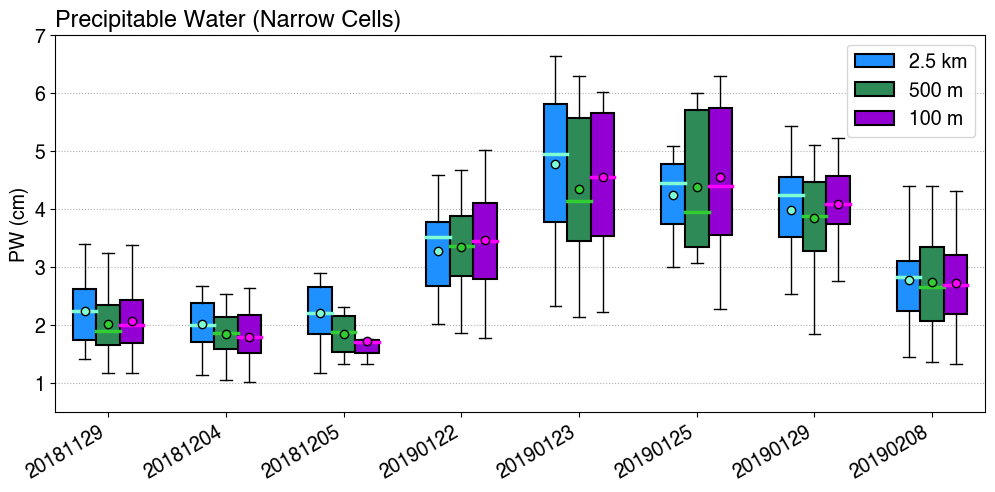

In [122]:
xlabel = start_dates
ylabel = 'PW (cm)'
title = 'Precipitable Water (Narrow Cells)'
ylim = (0.5,7)
fontsize = 14
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_PW_narrow_d2_d3_d4.png'
fig = plot_boxplots(PW_date_narrow_d2, PW_date_narrow_d3, PW_date_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

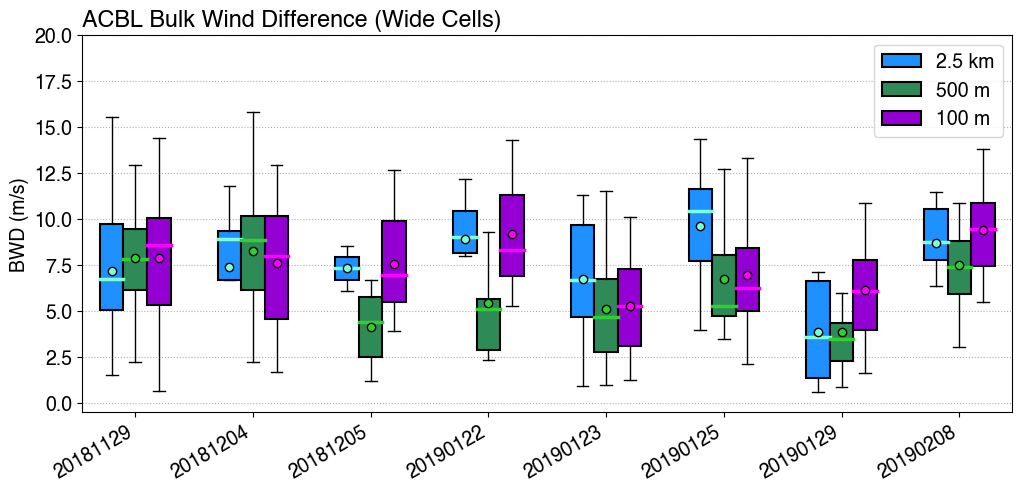

In [123]:
xlabel = start_dates
ylabel = 'BWD (m/s)'
title = 'ACBL Bulk Wind Difference (Wide Cells)'
ylim = (-0.5, 20)
fontsize = 14
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_BWSacbl_wide_d2_d3_d4.png'
fig = plot_boxplots(BWSacbl_date_wide_d2, BWSacbl_date_wide_d3, BWSacbl_date_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

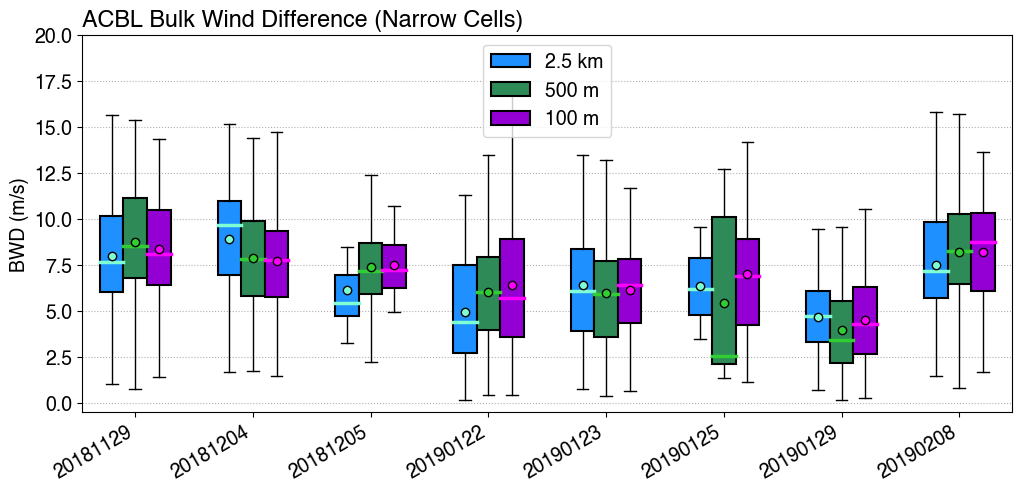

In [124]:
xlabel = start_dates
ylabel = 'BWD (m/s)'
title = 'ACBL Bulk Wind Difference (Narrow Cells)'
ylim = (-0.5, 20)
fontsize = 14
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_BWSacbl_narrow_d2_d3_d4.png'
fig = plot_boxplots(BWSacbl_date_narrow_d2, BWSacbl_date_narrow_d3, BWSacbl_date_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

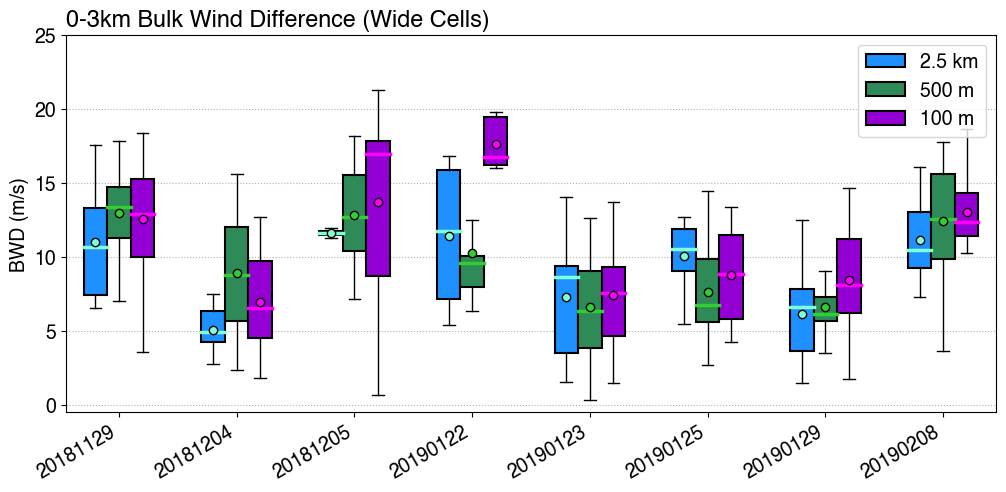

In [125]:
xlabel = start_dates
ylabel = 'BWD (m/s)'
title = '0-3km Bulk Wind Difference (Wide Cells)'
ylim = (-0.5, 25)
fontsize = 14
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_BWS03km_wide_d2_d3_d4.png'
fig = plot_boxplots(BWS03km_date_wide_d2, BWS03km_date_wide_d3, BWS03km_date_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

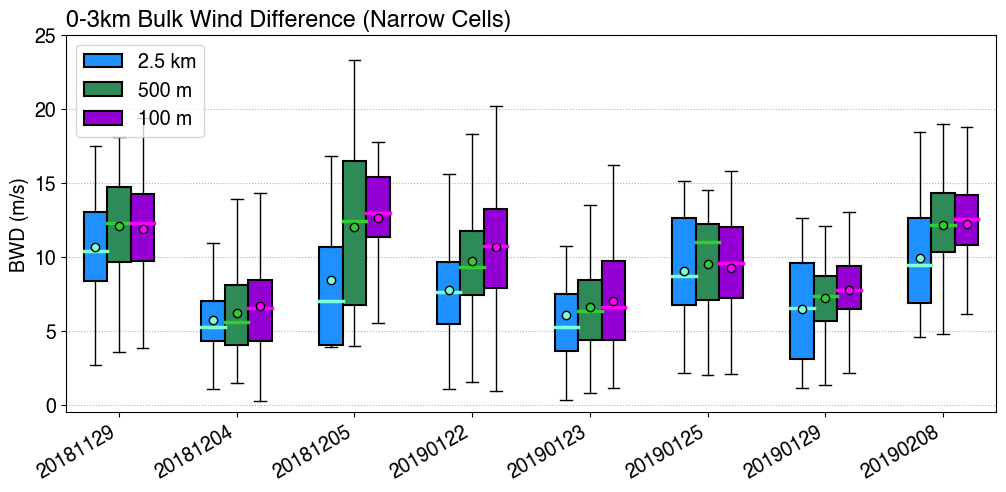

In [126]:
xlabel = start_dates
ylabel = 'BWD (m/s)'
title = '0-3km Bulk Wind Difference (Narrow Cells)'
ylim = (-0.5, 25)
fontsize = 14
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_BWS03km_narrow_d2_d3_d4.png'
fig = plot_boxplots(BWS03km_date_narrow_d2, BWS03km_date_narrow_d3, BWS03km_date_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

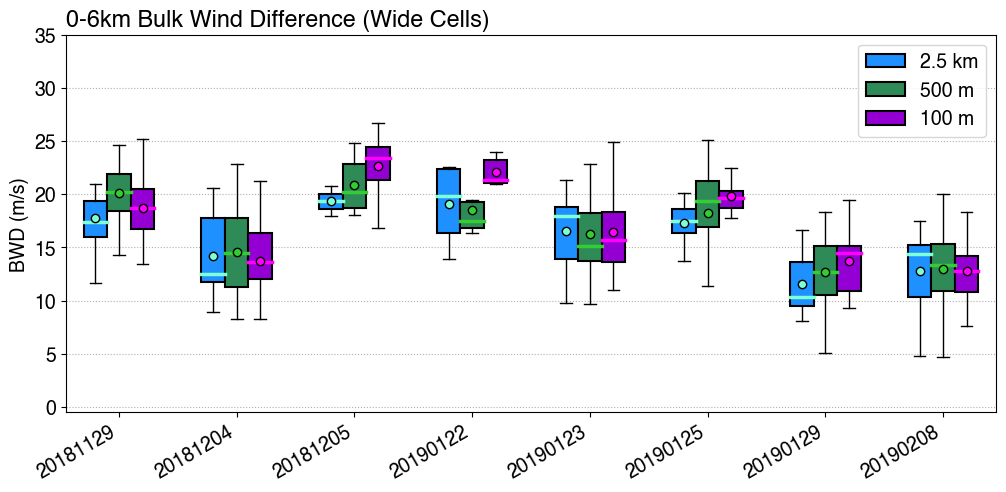

In [127]:
xlabel = start_dates
ylabel = 'BWD (m/s)'
title = '0-6km Bulk Wind Difference (Wide Cells)'
ylim = (-0.5, 35)
fontsize = 14
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_BWS06km_wide_d2_d3_d4.png'
fig = plot_boxplots(BWS06km_date_wide_d2, BWS06km_date_wide_d3, BWS06km_date_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

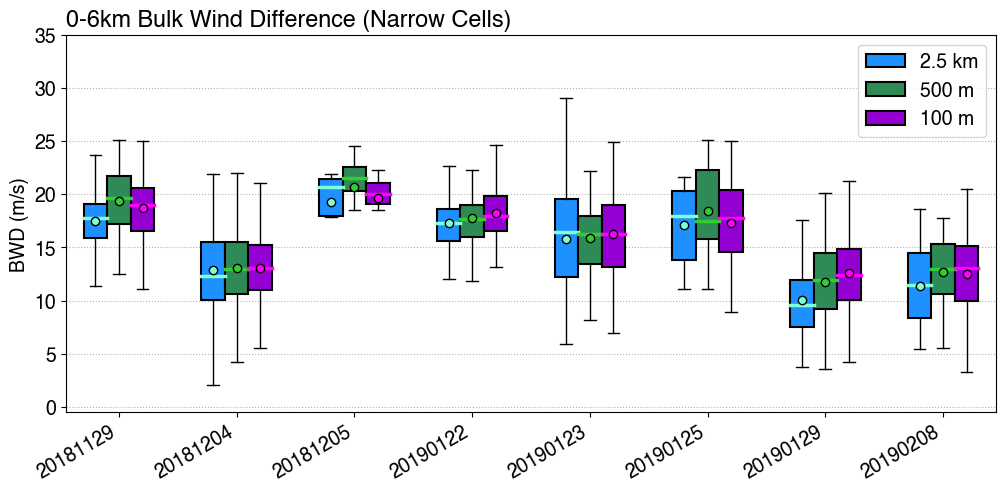

In [128]:
xlabel = start_dates
ylabel = 'BWD (m/s)'
title = '0-6km Bulk Wind Difference (Narrow Cells)'
ylim = (-0.5, 35)
fontsize = 14
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_BWS06km_narrow_d2_d3_d4.png'
fig = plot_boxplots(BWS06km_date_narrow_d2, BWS06km_date_narrow_d3, BWS06km_date_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, fontsize=fontsize)

## Make plots by case

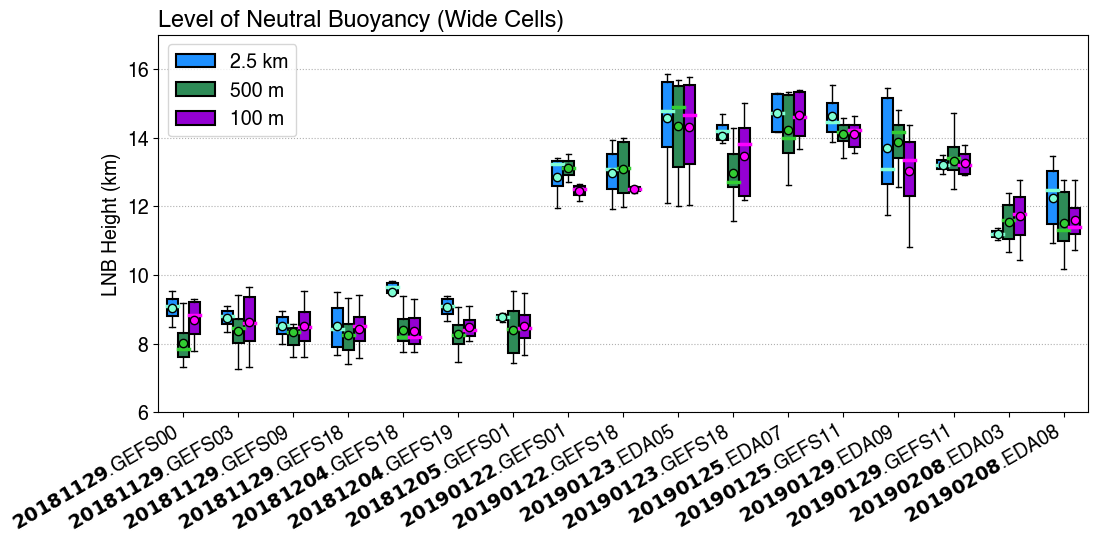

In [132]:
xlabel = uniq_CASES
ylabel = 'LNB Height (km)'
title = 'Level of Neutral Buoyancy (Wide Cells)'
ylim = (6,17)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_pELmu_wide_d2_d3_d4.png'
fig = plot_boxplots(pELmu_case_wide_d2, pELmu_case_wide_d3, pELmu_case_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

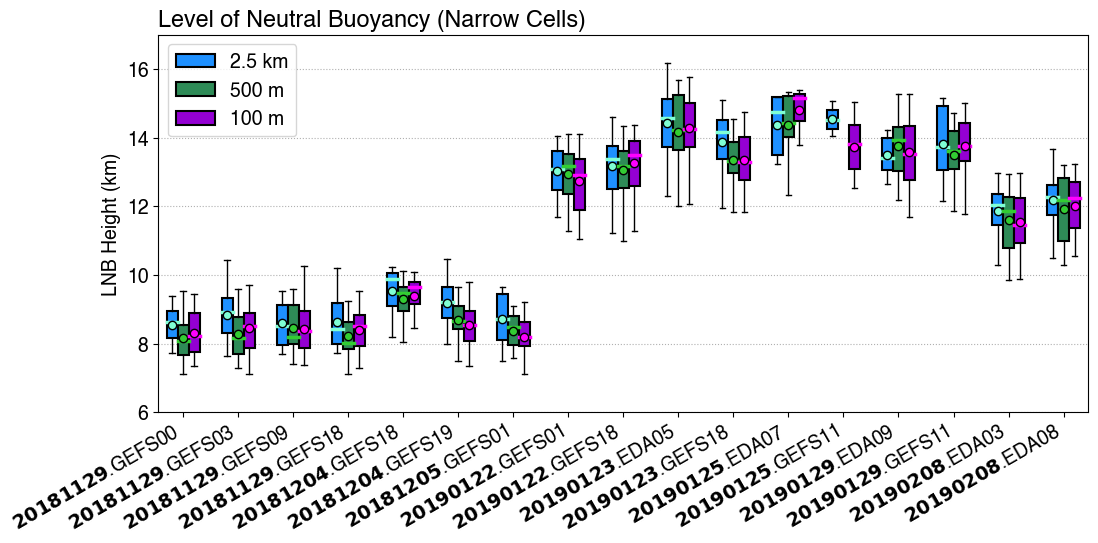

In [133]:
xlabel = uniq_CASES
ylabel = 'LNB Height (km)'
title = 'Level of Neutral Buoyancy (Narrow Cells)'
ylim = (6,17)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_pELmu_narrow_d2_d3_d4.png'
fig = plot_boxplots(pELmu_case_narrow_d2, pELmu_case_narrow_d3, pELmu_case_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

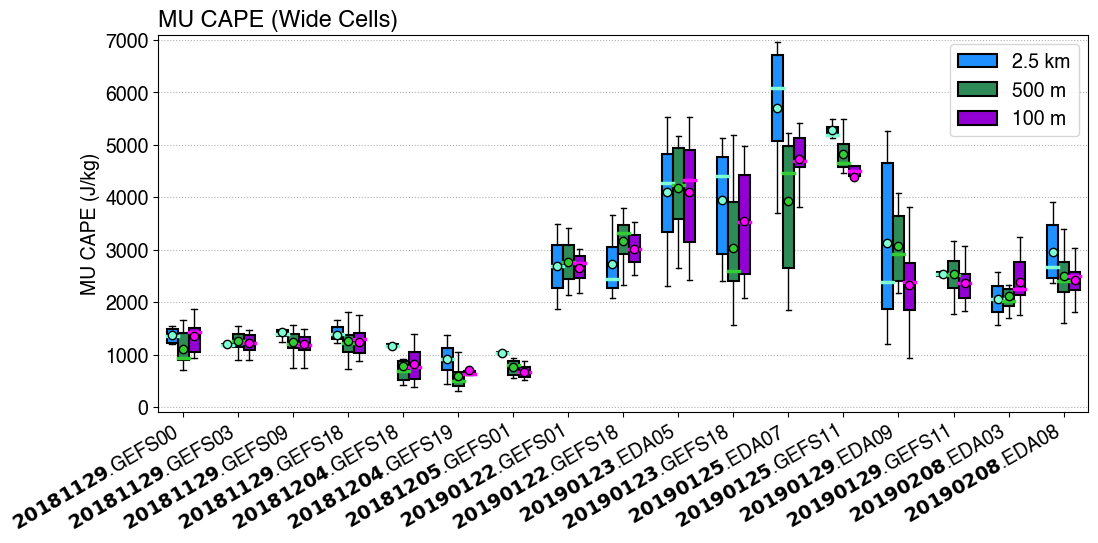

In [134]:
xlabel = uniq_CASES
ylabel = 'MU CAPE (J/kg)'
title = 'MU CAPE (Wide Cells)'
ylim = (-100,7100)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_pCAPEmu_wide_d2_d3_d4.png'
fig = plot_boxplots(pCAPEmu_case_wide_d2, pCAPEmu_case_wide_d3, pCAPEmu_case_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

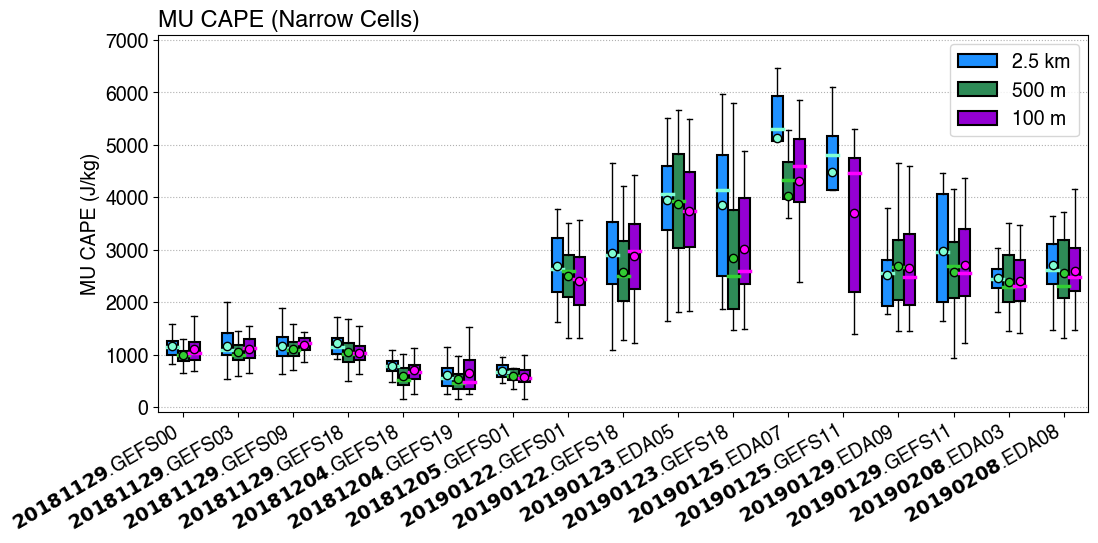

In [135]:
xlabel = uniq_CASES
ylabel = 'MU CAPE (J/kg)'
title = 'MU CAPE (Narrow Cells)'
ylim = (-100,7100)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_pCAPEmu_narrow_d2_d3_d4.png'
fig = plot_boxplots(pCAPEmu_case_narrow_d2, pCAPEmu_case_narrow_d3, pCAPEmu_case_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

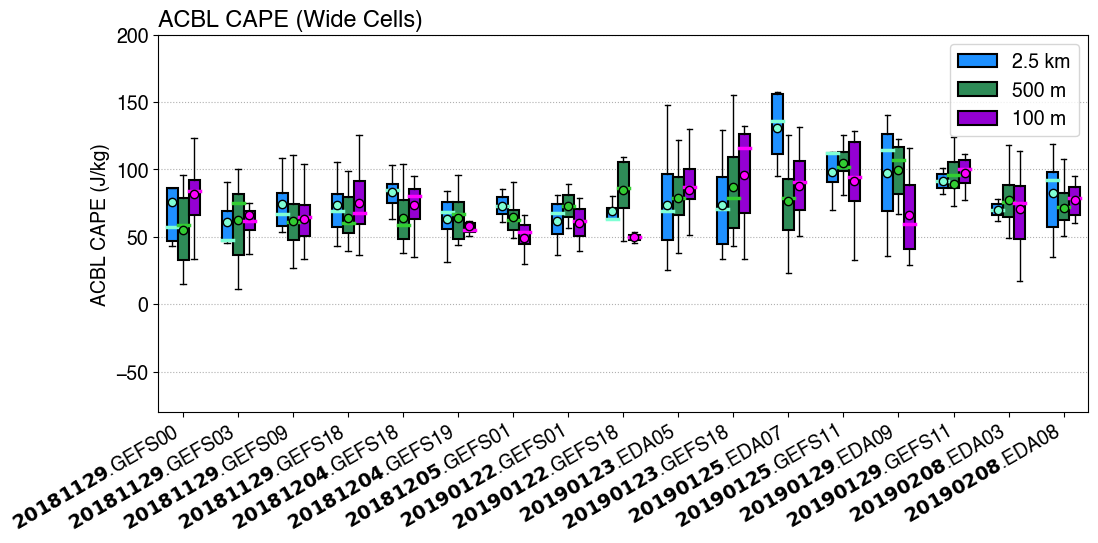

In [136]:
xlabel = uniq_CASES
ylabel = 'ACBL CAPE (J/kg)'
title = 'ACBL CAPE (Wide Cells)'
ylim = (-80,200)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_pCAPEacbl_wide_d2_d3_d4.png'
fig = plot_boxplots(pCAPEacbl_case_wide_d2, pCAPEacbl_case_wide_d3, pCAPEacbl_case_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

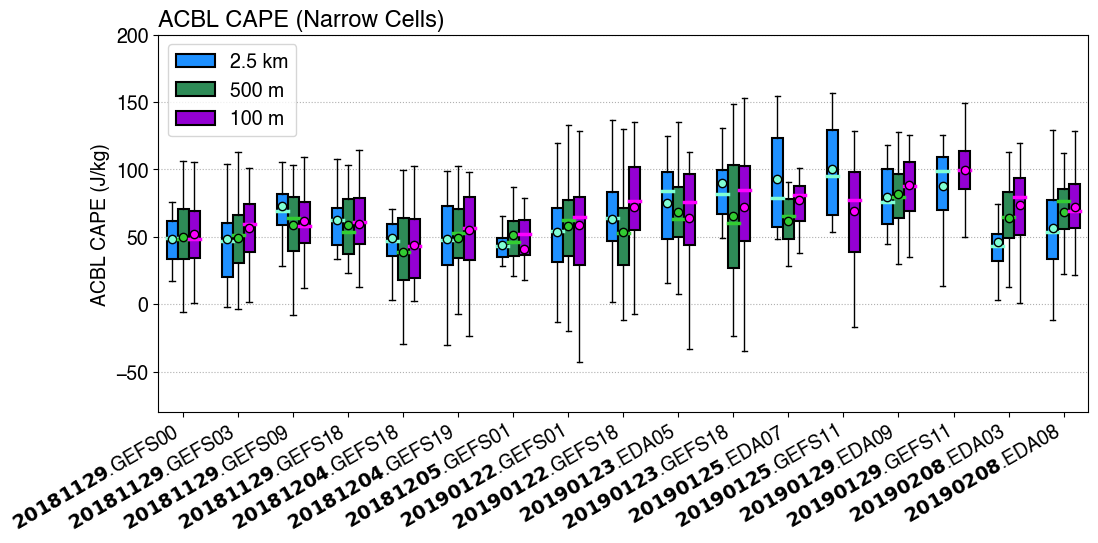

In [137]:
xlabel = uniq_CASES
ylabel = 'ACBL CAPE (J/kg)'
title = 'ACBL CAPE (Narrow Cells)'
ylim = (-80,200)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_pCAPEacbl_narrow_d2_d3_d4.png'
fig = plot_boxplots(pCAPEacbl_case_narrow_d2, pCAPEacbl_case_narrow_d3, pCAPEacbl_case_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

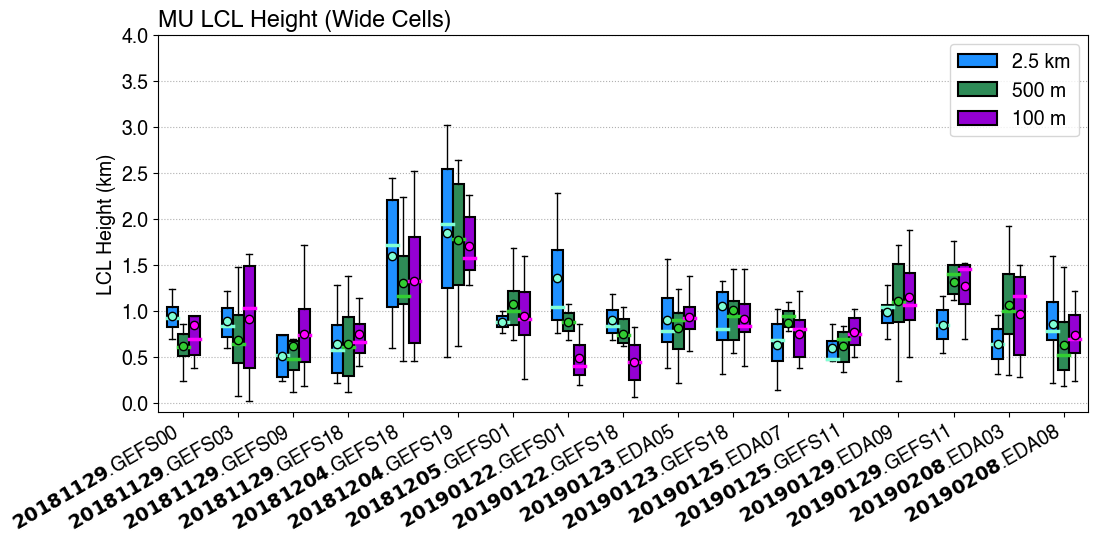

In [138]:
xlabel = uniq_CASES
ylabel = 'LCL Height (km)'
title = 'MU LCL Height (Wide Cells)'
ylim = (-0.1,4)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_pLCLmu_wide_d2_d3_d4.png'
fig = plot_boxplots(pLCLz_case_wide_d2, pLCLz_case_wide_d3, pLCLz_case_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

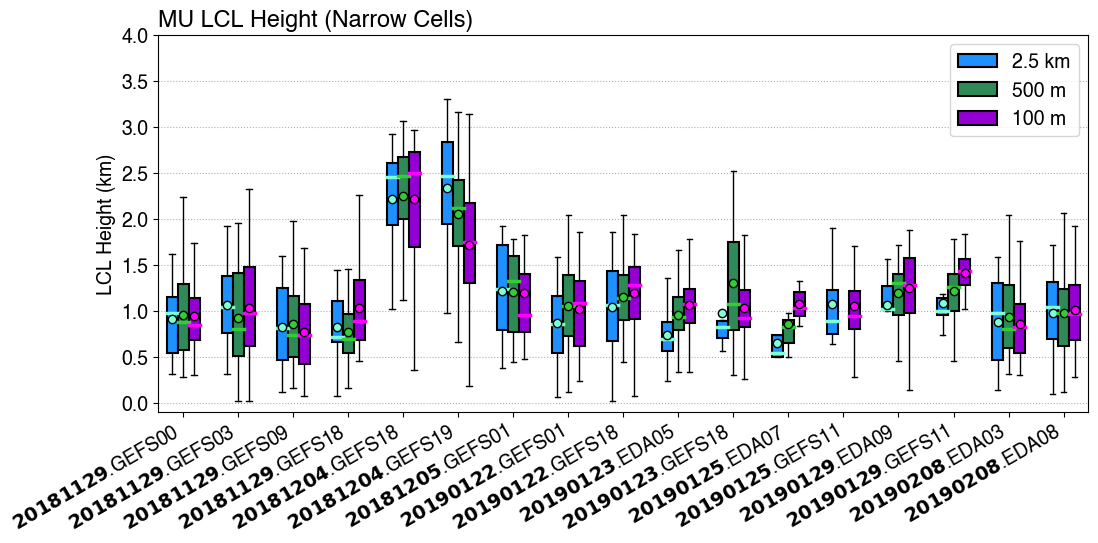

In [139]:
xlabel = uniq_CASES
ylabel = 'LCL Height (km)'
title = 'MU LCL Height (Narrow Cells)'
ylim = (-0.1,4)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_pLCLmu_narrow_d2_d3_d4.png'
fig = plot_boxplots(pLCLz_case_narrow_d2, pLCLz_case_narrow_d3, pLCLz_case_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

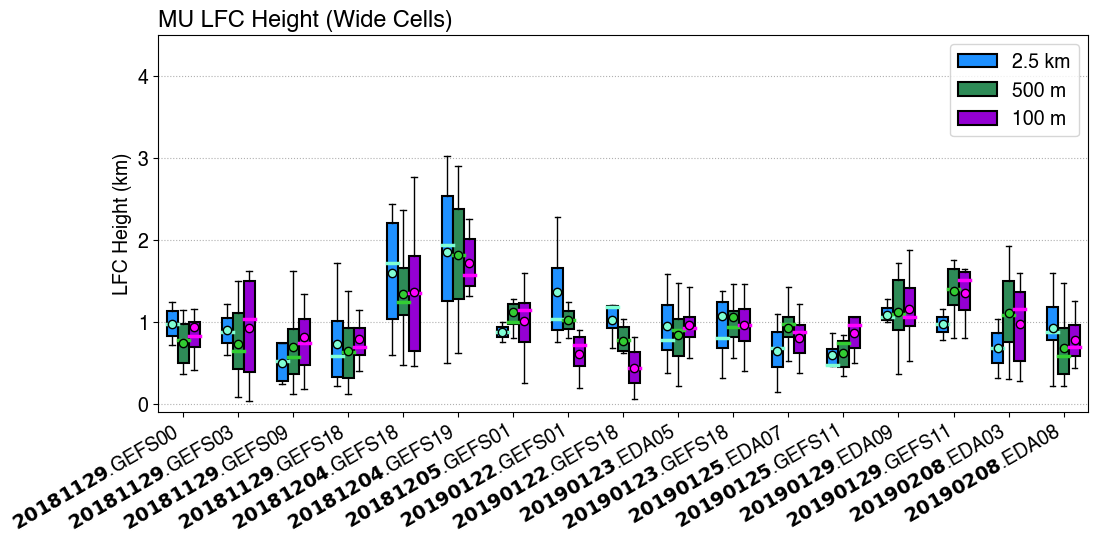

In [140]:
xlabel = uniq_CASES
ylabel = 'LFC Height (km)'
title = 'MU LFC Height (Wide Cells)'
ylim = (-0.1,4.5)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_pLFCmu_wide_d2_d3_d4.png'
fig = plot_boxplots(pLFCz_case_wide_d2, pLFCz_case_wide_d3, pLFCz_case_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

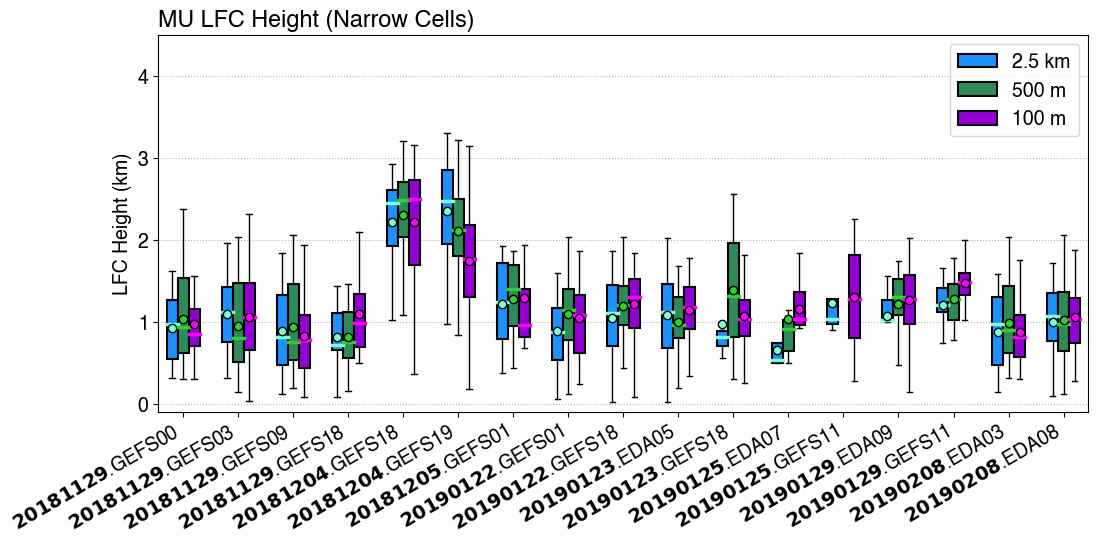

In [141]:
xlabel = uniq_CASES
ylabel = 'LFC Height (km)'
title = 'MU LFC Height (Narrow Cells)'
ylim = (-0.1,4.5)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_pLFCmu_narrow_d2_d3_d4.png'
fig = plot_boxplots(pLFCz_case_narrow_d2, pLFCz_case_narrow_d3, pLFCz_case_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

In [167]:
# xlabel = uniq_CASES
# ylabel = 'RH (%)'
# title = 'ACBL RH (Wide Cells)'
# ylim = (10,102)
# figsize = [12,5]
# figname = f'{figdir}BoxplotByCase_RHacbl_wide_d2_d3_d4.png'
# fig = plot_boxplots(RHacbl_case_wide_d2, RHacbl_case_wide_d3, RHacbl_case_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

In [168]:
# xlabel = uniq_CASES
# ylabel = 'RH (%)'
# title = 'ACBL RH (Narrow Cells)'
# ylim = (10,102)
# figsize = [12,5]
# figname = f'{figdir}BoxplotByCase_RHacbl_narrow_d2_d3_d4.png'
# fig = plot_boxplots(RHacbl_case_narrow_d2, RHacbl_case_narrow_d3, RHacbl_case_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

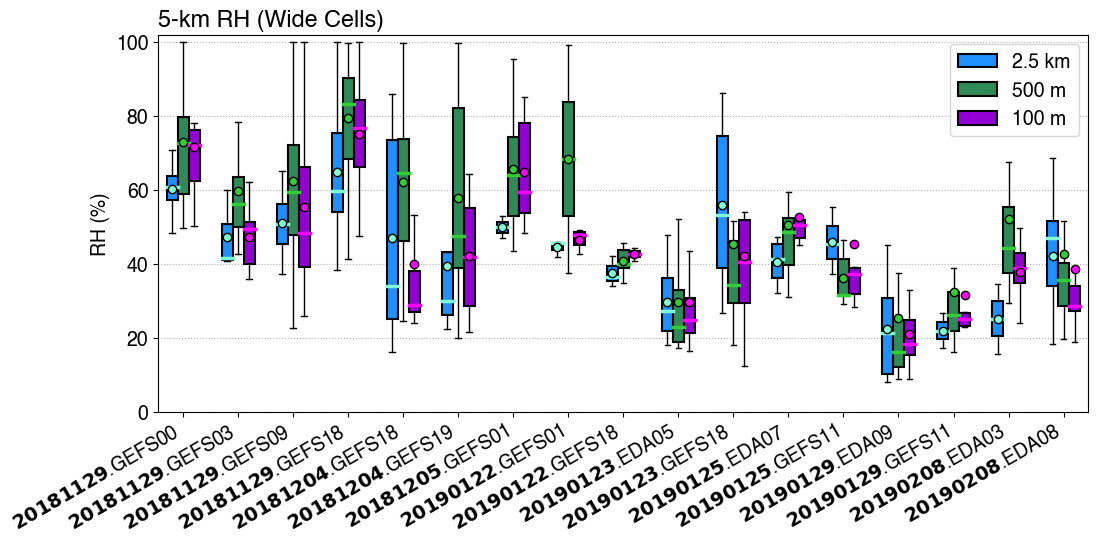

In [144]:
xlabel = uniq_CASES
ylabel = 'RH (%)'
title = '5-km RH (Wide Cells)'
ylim = (0,102)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_RH5km_wide_d2_d3_d4.png'
fig = plot_boxplots(RH5km_case_wide_d2, RH5km_case_wide_d3, RH5km_case_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

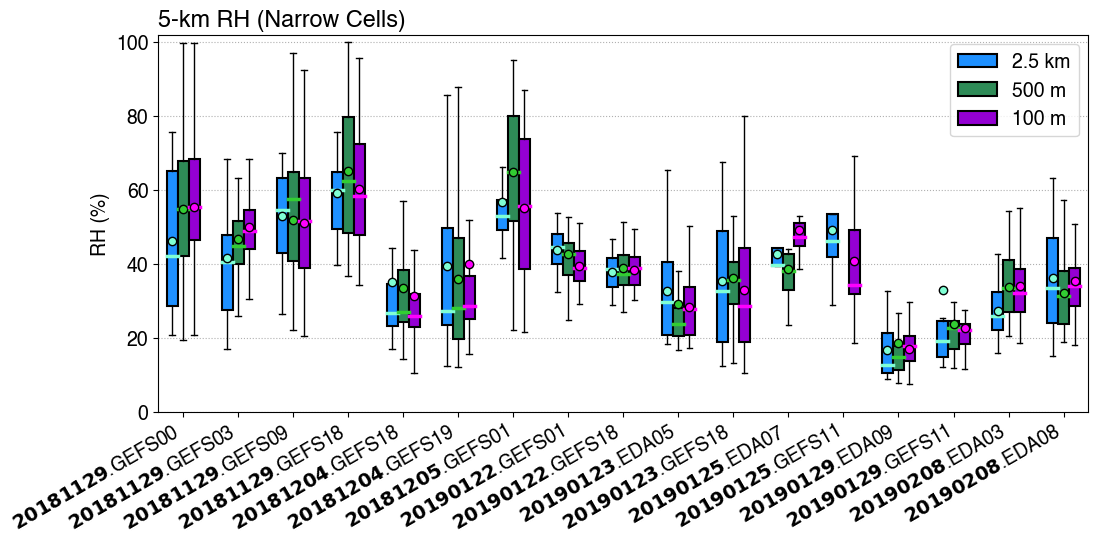

In [145]:
xlabel = uniq_CASES
ylabel = 'RH (%)'
title = '5-km RH (Narrow Cells)'
ylim = (0,102)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_RH5km_narrow_d2_d3_d4.png'
fig = plot_boxplots(RH5km_case_narrow_d2, RH5km_case_narrow_d3, RH5km_case_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

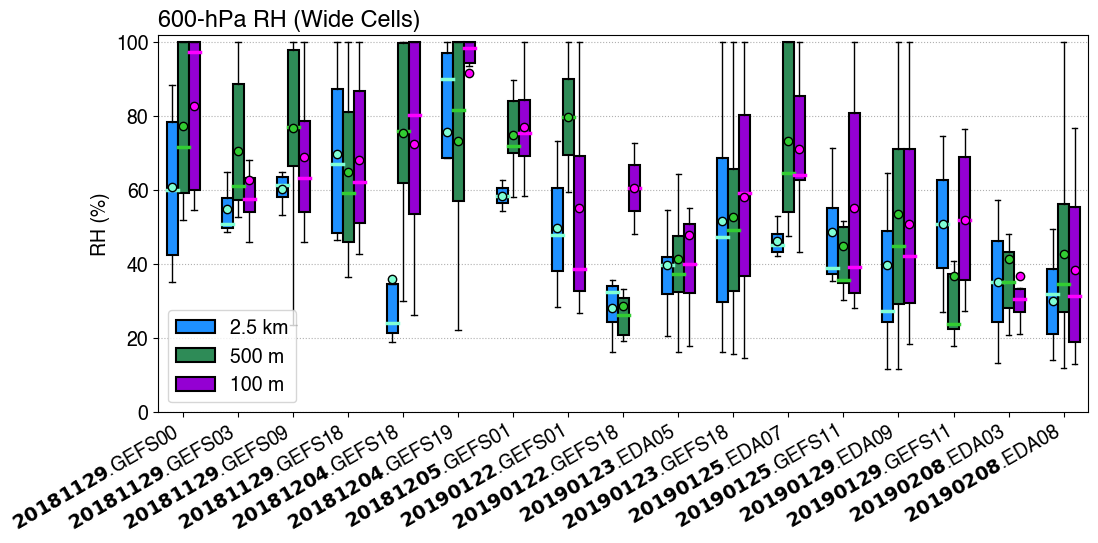

In [169]:
xlabel = uniq_CASES
ylabel = 'RH (%)'
title = '600-hPa RH (Wide Cells)'
ylim = (0,102)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_RH600mb_wide_d2_d3_d4.png'
fig = plot_boxplots(RH600mb_case_wide_d2, RH600mb_case_wide_d3, RH600mb_case_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

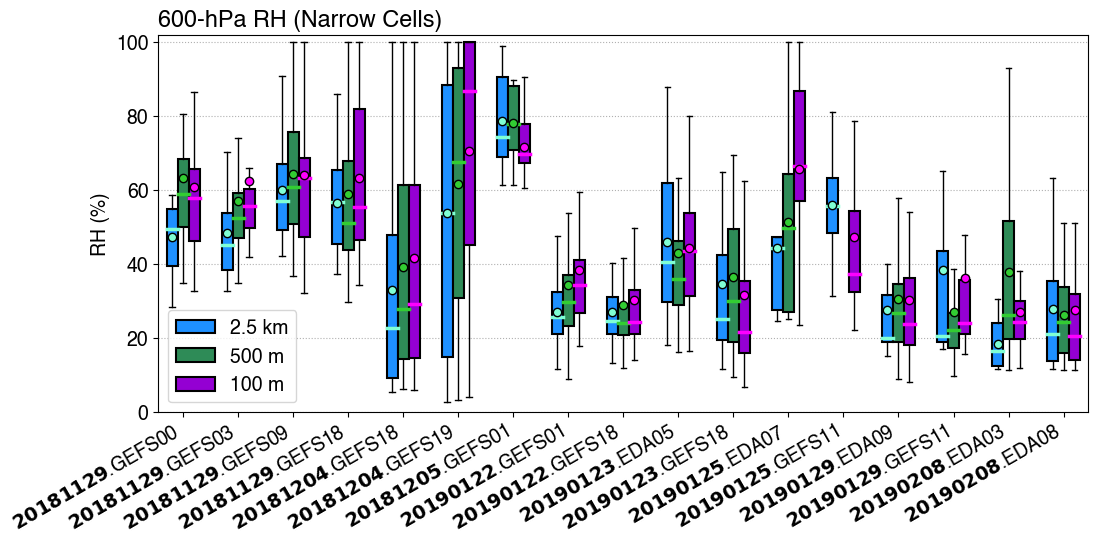

In [170]:
xlabel = uniq_CASES
ylabel = 'RH (%)'
title = '600-hPa RH (Narrow Cells)'
ylim = (0,102)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_RH600mb_narrow_d2_d3_d4.png'
fig = plot_boxplots(RH600mb_case_narrow_d2, RH600mb_case_narrow_d3, RH600mb_case_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

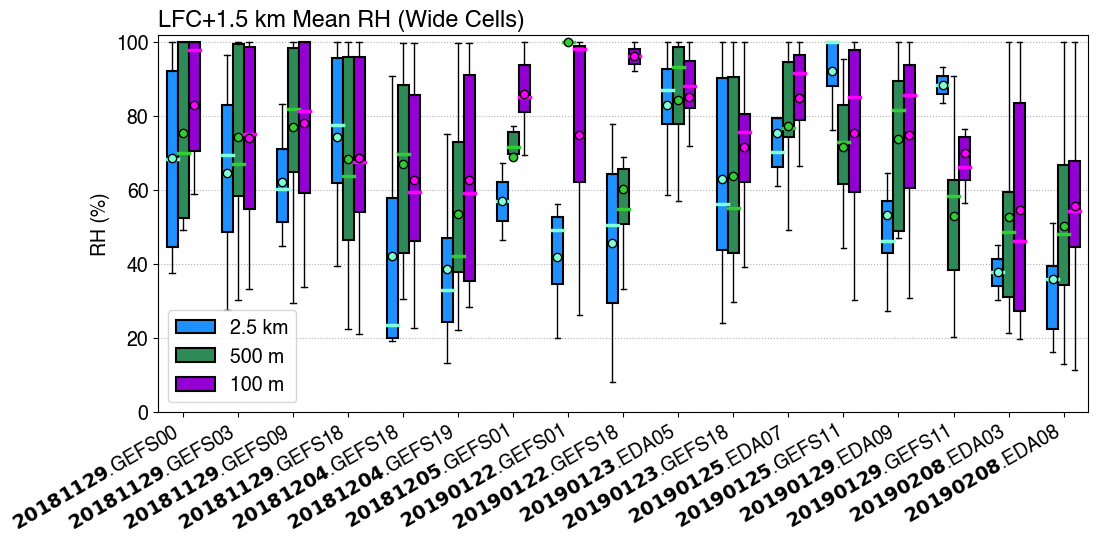

In [148]:
xlabel = uniq_CASES
ylabel = 'RH (%)'
title = 'LFC+1.5 km Mean RH (Wide Cells)'
ylim = (0,102)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_RHlfc1500m_wide_d2_d3_d4.png'
fig = plot_boxplots(RHlfc1500_case_wide_d2, RHlfc1500_case_wide_d3, RHlfc1500_case_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

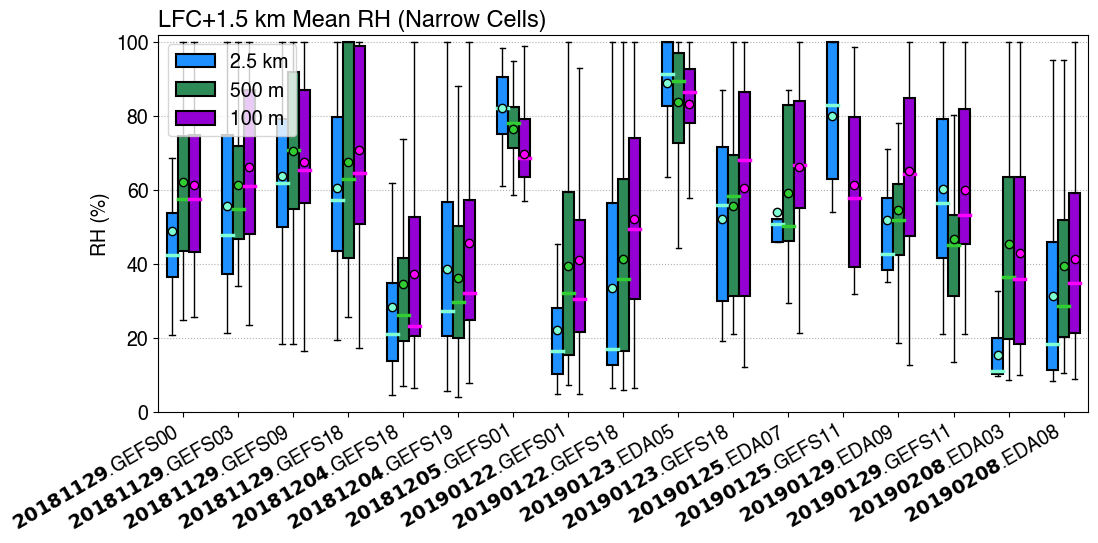

In [149]:
xlabel = uniq_CASES
ylabel = 'RH (%)'
title = 'LFC+1.5 km Mean RH (Narrow Cells)'
ylim = (0,102)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_RHlfc1500m_narrow_d2_d3_d4.png'
fig = plot_boxplots(RHlfc1500_case_narrow_d2, RHlfc1500_case_narrow_d3, RHlfc1500_case_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

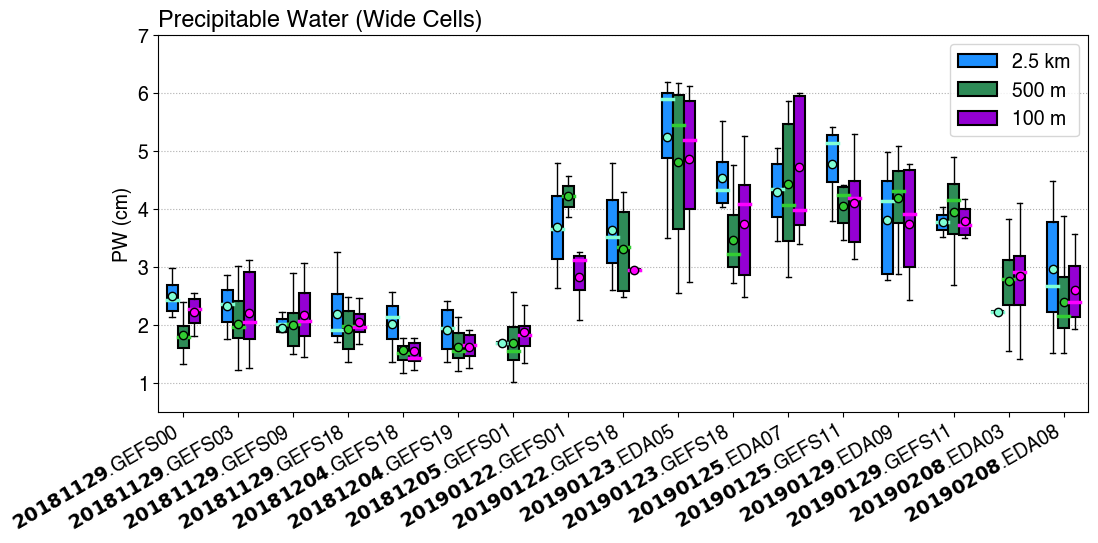

In [150]:
xlabel = uniq_CASES
ylabel = 'PW (cm)'
title = 'Precipitable Water (Wide Cells)'
ylim = (0.5,7)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_PW_wide_d2_d3_d4.png'
fig = plot_boxplots(PW_case_wide_d2, PW_case_wide_d3, PW_case_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

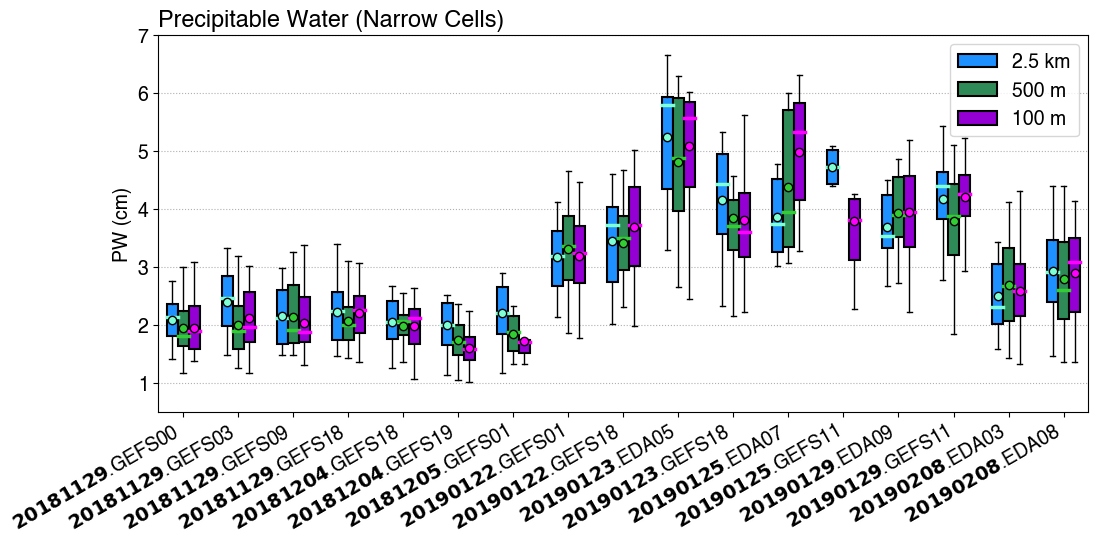

In [151]:
xlabel = uniq_CASES
ylabel = 'PW (cm)'
title = 'Precipitable Water (Narrow Cells)'
ylim = (0.5,7)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_PW_narrow_d2_d3_d4.png'
fig = plot_boxplots(PW_case_narrow_d2, PW_case_narrow_d3, PW_case_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

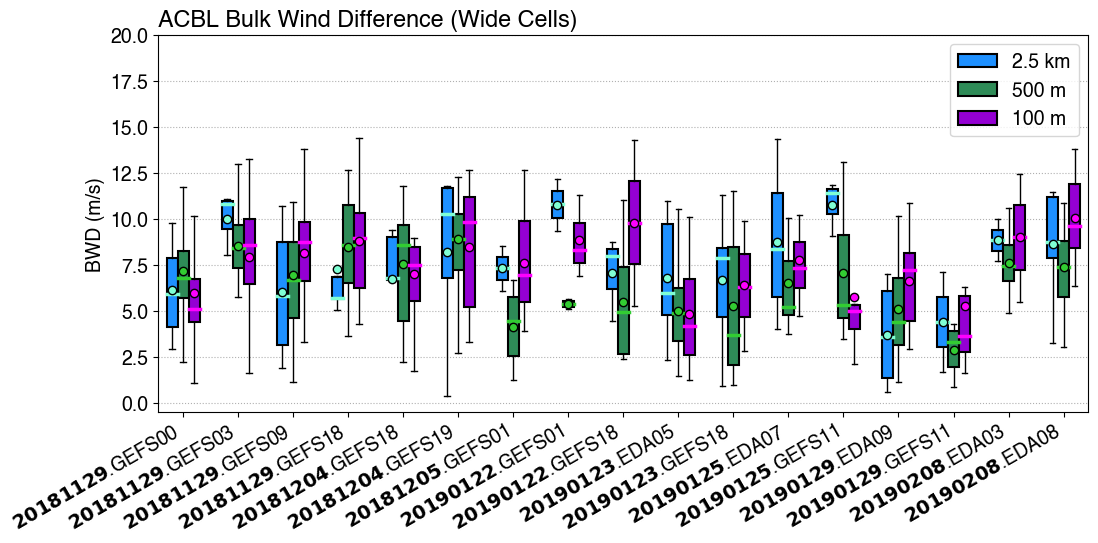

In [152]:
xlabel = uniq_CASES
ylabel = 'BWD (m/s)'
title = 'ACBL Bulk Wind Difference (Wide Cells)'
ylim = (-0.5,20)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_BWSacbl_wide_d2_d3_d4.png'
fig = plot_boxplots(BWSacbl_case_wide_d2, BWSacbl_case_wide_d3, BWSacbl_case_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

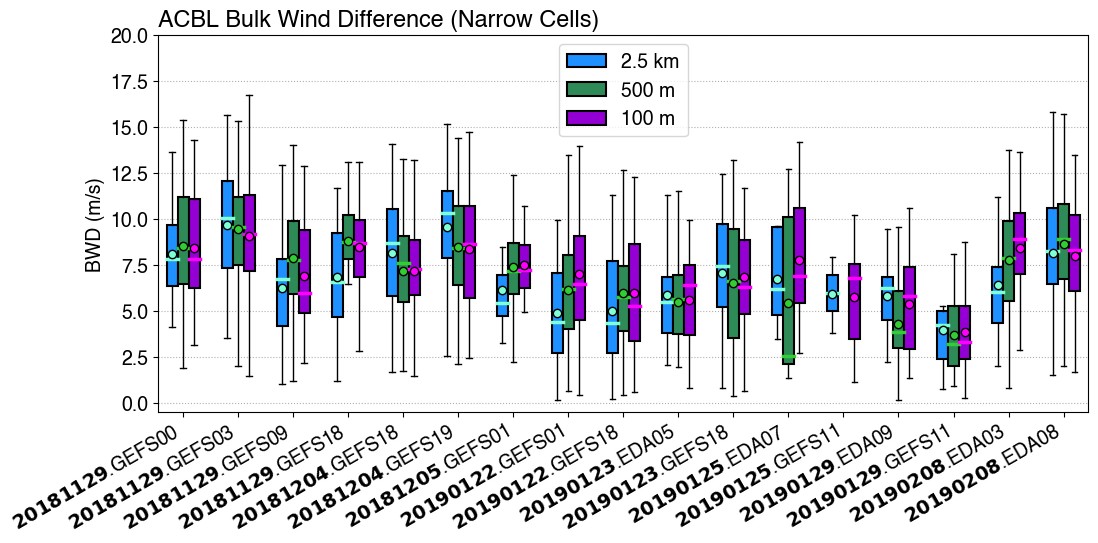

In [153]:
xlabel = uniq_CASES
ylabel = 'BWD (m/s)'
title = 'ACBL Bulk Wind Difference (Narrow Cells)'
ylim = (-0.5,20)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_BWSacbl_narrow_d2_d3_d4.png'
fig = plot_boxplots(BWSacbl_case_narrow_d2, BWSacbl_case_narrow_d3, BWSacbl_case_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

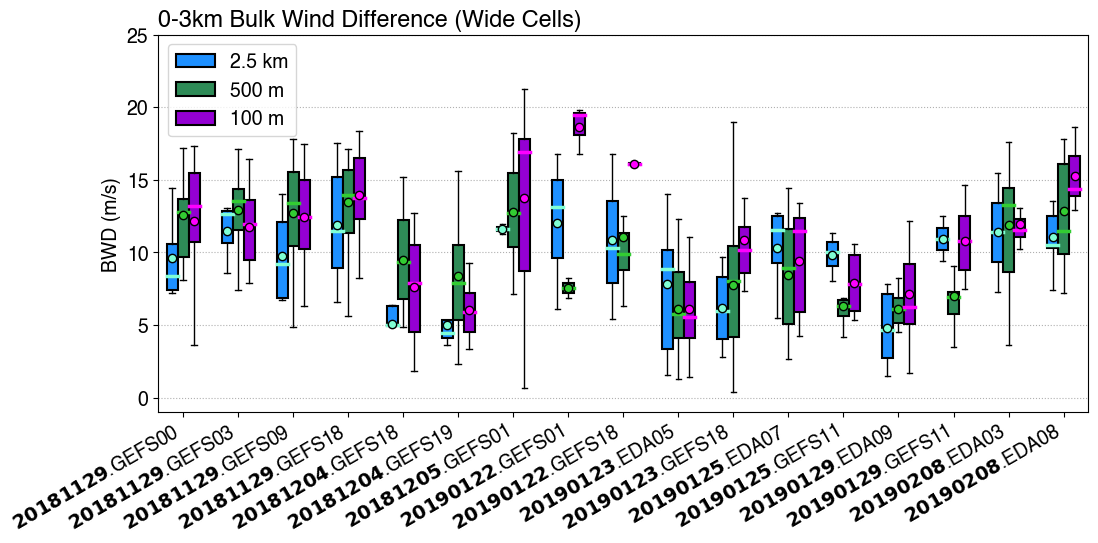

In [154]:
xlabel = uniq_CASES
ylabel = 'BWD (m/s)'
title = '0-3km Bulk Wind Difference (Wide Cells)'
ylim = (-1,25)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_BWS03km_wide_d2_d3_d4.png'
fig = plot_boxplots(BWS03km_case_wide_d2, BWS03km_case_wide_d3, BWS03km_case_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

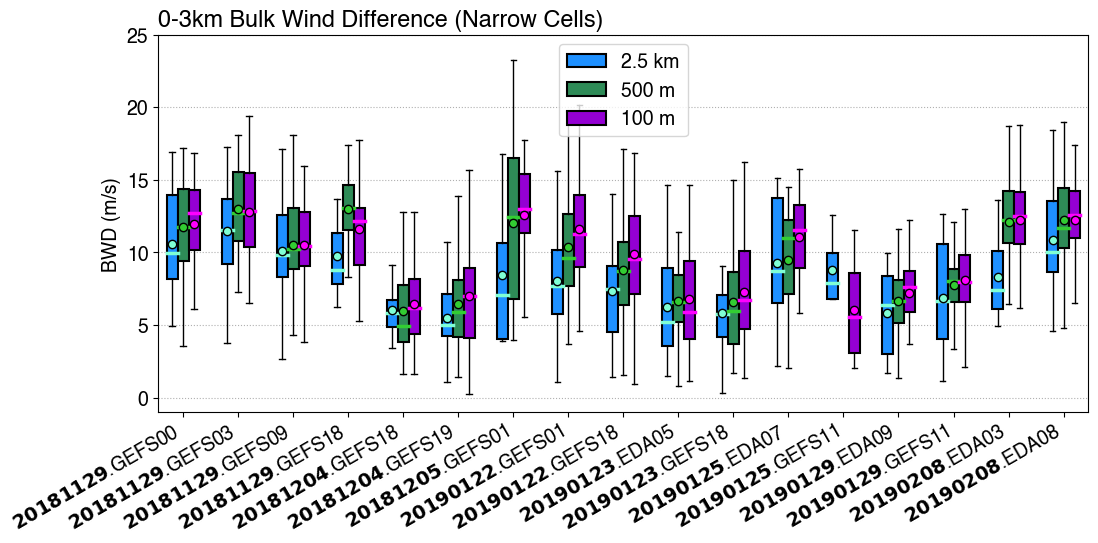

In [155]:
xlabel = uniq_CASES
ylabel = 'BWD (m/s)'
title = '0-3km Bulk Wind Difference (Narrow Cells)'
ylim = (-1,25)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_BWS03km_narrow_d2_d3_d4.png'
fig = plot_boxplots(BWS03km_case_narrow_d2, BWS03km_case_narrow_d3, BWS03km_case_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

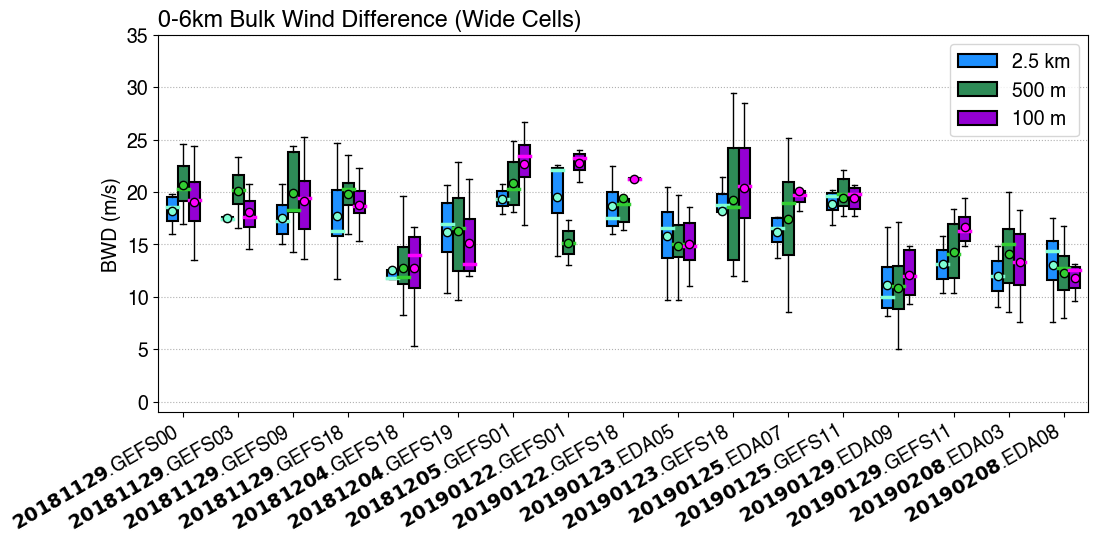

In [156]:
xlabel = uniq_CASES
ylabel = 'BWD (m/s)'
title = '0-6km Bulk Wind Difference (Wide Cells)'
ylim = (-1,35)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_BWS06km_wide_d2_d3_d4.png'
fig = plot_boxplots(BWS06km_case_wide_d2, BWS06km_case_wide_d3, BWS06km_case_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

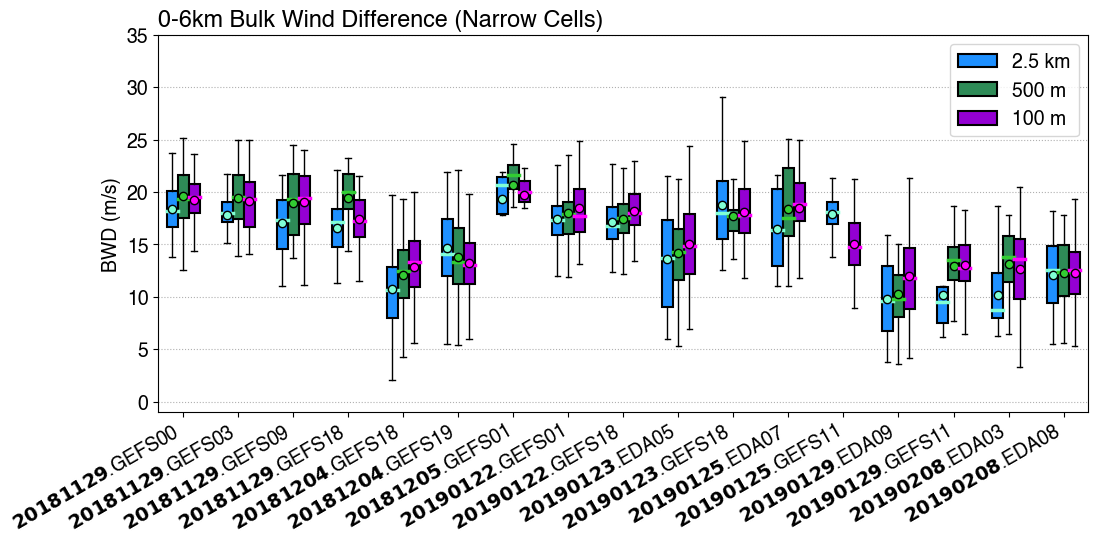

In [157]:
xlabel = uniq_CASES
ylabel = 'BWD (m/s)'
title = '0-6km Bulk Wind Difference (Narrow Cells)'
ylim = (-1,35)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_BWS06km_narrow_d2_d3_d4.png'
fig = plot_boxplots(BWS06km_case_narrow_d2, BWS06km_case_narrow_d3, BWS06km_case_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)